# PCA - Erdbeere Gesamt v2 · Without Threshold · Without OdourType · Iterative Outlier Removal

**Version:** v2 – no OAV / olfactory threshold, no OdourType grouping.
**Goal:** PCA purely on aroma substances (CAS) and normalised recipe proportions.
**Pipeline:** Remove ignore-list substances (CAS-based) → normalise Totalmenge per recipe →
**Iterative outlier removal** (max 20 iterations): detect outlier(s) in PC1/PC2 space,
note them, remove them, repeat until no outliers remain or max iterations reached.
At each iteration a plot is produced and outlier recipe IDs are recorded.

**Dataset:** `data/gold/Third_Trial_Set_PDM Erdbeere Gesamt 8-5-2026.csv`
**Outputs:** `outputs/pca_v2_noOT_*`

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from pathlib import Path

# ── paths ──────────────────────────────────────────────────────────────────
BASE      = Path('..')
DATA_PATH = BASE / 'data/gold/Third_Trial_Set_PDM Erdbeere Gesamt 8-5-2026.csv'
OUT_DIR   = BASE / 'outputs'
OUT_DIR.mkdir(exist_ok=True)
IGNORE_PATH = BASE / 'data/gold/ignone_substances.csv'

print('Libraries loaded ✓')

Libraries loaded ✓


## 1 · Load & Clean Data

In [2]:
def parse_de_float(val):
    if pd.isna(val):
        return float('nan')
    s = str(val).strip().replace(',', '.')
    try:
        return float(s)
    except ValueError:
        return float('nan')

df = pd.read_csv(DATA_PATH, dtype=str)
df['Totalmenge'] = df['Totalmenge'].apply(parse_de_float)
df['Threshold']  = df['Threshold'].apply(parse_de_float)

print(f'Raw rows: {len(df):,}')
print(f'Unique recipes (Rez.-Nr.): {df["Rez.-Nr."].nunique()}')
print(f'Unique ingredients (Ident): {df["Ident"].nunique()}')
print(f'Unique CAS numbers: {df["CAS-Nr."].nunique()}')

Raw rows: 3,369
Unique recipes (Rez.-Nr.): 130
Unique ingredients (Ident): 338
Unique CAS numbers: 231


In [3]:
# ── Apply ignore list ────────────────────────────────────────────────────────
if IGNORE_PATH.exists():
    ign             = pd.read_csv(IGNORE_PATH)
    ign_idents      = set(ign['Ident'].dropna().astype(str).str.strip())
    names_to_ignore = {str(n).lower().strip() for n in ign['Name']}
    mask = (
        df['Ident'].astype(str).str.strip().isin(ign_idents) |
        df['Name'].str.lower().str.strip().isin(names_to_ignore)
    )
    cas_to_ignore = set(df.loc[mask, 'CAS-Nr.'].dropna().astype(str).str.strip())
    df.loc[df['CAS-Nr.'].astype(str).str.strip().isin(cas_to_ignore), 'Totalmenge'] = 0.0
    print(f'Ignored idents: {len(ign_idents)} | Ignored CAS numbers: {len(cas_to_ignore)}')
else:
    print('No ignore list found — all ingredients included.')

Ignored idents: 10 | Ignored CAS numbers: 6


In [4]:
# -- Normalize Totalmenge per recipe (no threshold, no OAV) ------------------
df_t = df[df['Totalmenge'] > 0].copy()

per_recipe_sum = df_t.groupby('Rez.-Nr.')['Totalmenge'].transform('sum')
df_t['Norm_Totalmenge'] = df_t['Totalmenge'] / per_recipe_sum

print(f'Rows with positive Totalmenge: {len(df_t):,}')
print(f'Recipes after filtering      : {df_t["Rez.-Nr."].nunique()}')
print(f'Unique CAS numbers retained  : {df_t["CAS-Nr."].nunique()}')
print()
print('Norm_Totalmenge distribution:')
print(df_t['Norm_Totalmenge'].describe().round(5))

Rows with positive Totalmenge: 3,155
Recipes after filtering      : 130
Unique CAS numbers retained  : 225

Norm_Totalmenge distribution:
count    3155.00000
mean        0.04120
std         0.10592
min         0.00000
25%         0.00093
50%         0.00661
75%         0.03654
max         1.00000
Name: Norm_Totalmenge, dtype: float64


In [5]:
# -- Build Recipe x CAS Normalized Totalmenge matrix --------------------------
pivot_oav = df_t.pivot_table(
    index='Rez.-Nr.', columns='CAS-Nr.',
    values='Norm_Totalmenge', aggfunc='sum', fill_value=0
)
print(f'Recipe x CAS matrix       : {pivot_oav.shape}')
print(f'Avg CAS per recipe        : {(pivot_oav > 0).sum(axis=1).mean():.1f}')
print(f'Matrix value range        : {pivot_oav.values.min():.5f} - {pivot_oav.values.max():.5f}')

# No log transformation — normalised proportions are already on a comparable scale
X_oav = pivot_oav.values.copy()

Recipe x CAS matrix       : (129, 225)
Avg CAS per recipe        : 23.8
Matrix value range        : 0.00000 - 0.78706


In [6]:
# -- Ingredient Statistics: Frequency & Average (after removal + normalisation) --
cas_name_full = df.groupby('CAS-Nr.')['Name'].first().to_dict()

freq      = (pivot_oav > 0).mean(axis=0)
n_recipes = (pivot_oav > 0).sum(axis=0)

avg_present_mat = pivot_oav.copy()
avg_present_mat[avg_present_mat == 0] = np.nan
avg_when_present = avg_present_mat.mean(axis=0)
avg_all = pivot_oav.mean(axis=0)

ing_stats = pd.DataFrame({
    'CAS':                   pivot_oav.columns,
    'Ingredient':            [cas_name_full.get(c, c) for c in pivot_oav.columns],
    'Frequency':             freq.values.round(4),
    'Recipes_Count':         n_recipes.values,
    'Avg_Norm_When_Present': avg_when_present.values.round(6),
    'Avg_Norm_All_Recipes':  avg_all.values.round(6),
}).sort_values('Frequency', ascending=False).reset_index(drop=True)

print(f'Ingredient statistics for {len(ing_stats)} unique CAS numbers '
      f'across {len(pivot_oav)} recipes')
print()
print(ing_stats.head(30).to_string(index=False))

ing_stats.to_csv(OUT_DIR / 'pca_v2_noOT_ingredient_statistics.csv', index=False)
ing_stats.to_excel(OUT_DIR / 'pca_v2_noOT_ingredient_statistics.xlsx', index=False)
print('\nExported: pca_v2_noOT_ingredient_statistics.csv / .xlsx')

Ingredient statistics for 225 unique CAS numbers across 129 recipes

       CAS                                      Ingredient  Frequency  Recipes_Count  Avg_Norm_When_Present  Avg_Norm_All_Recipes
  105-54-4                       Ethylbutyrat Kosher Halal     0.9922            128               0.093956              0.093228
  706-14-9                   gamma-Decalacton Kosher Halal     0.9302            120               0.038739              0.036037
  123-66-0                             Ethylhexanoat Halal     0.9225            119               0.036157              0.033354
 7452-79-1              Ethyl-2-methylbutyrat Kosher Halal     0.9147            118               0.048705              0.044552
  928-96-1                   cis-3-Hexen-1-ol Halal Kosher     0.8992            116               0.088893              0.079935
  116-53-0                2-Methylbuttersäure Halal Kosher     0.8140            105               0.063624              0.051787
 3658-77-3           

## 2 · Iterative PCA – Outlier Detection & Removal

**Method:** At each iteration:
1. Fit PCA on the current recipe set.
2. Compute z-scores of PC1 and PC2 scores across all active recipes.
3. Compute 2D Mahalanobis distance: `d = sqrt(z1² + z2²)`.
4. Flag recipes with `d > Z_THRESH` as outliers (capped at `MAX_REMOVE_PER_IT = 3` per iteration, worst-first).
5. Plot all recipes; outliers are marked in red with recipe ID labels.
6. Remove outliers → repeat.
7. Stop when no outliers remain or after `MAX_ITER = 20` iterations.

The **final clean dataset** is used for all subsequent analyses.

---

### What does the 4.5σ threshold mean?

**Step by step:**

1. After PCA, every recipe gets a score on PC1 and PC2.
2. Those scores are standardised to z-scores:
   - `z1 = (PC1_score − mean(PC1)) / std(PC1)`
   - `z2 = (PC2_score − mean(PC2)) / std(PC2)`
3. A single **distance from the centroid** is computed:
   - `d = sqrt(z1² + z2²)`
4. Any recipe with `d > 4.5` is flagged as an outlier.

**Geometrically:** this is the radius of an ellipse in PC1–PC2 space centred on the average recipe. The ellipse's axes are `4.5 × std(PC1)` and `4.5 × std(PC2)`. Recipes **outside** this ellipse are removed.

**What it is NOT:** 4.5 standard deviations above/below the mean on a single axis. A recipe at 3σ on PC1 *and* 3σ on PC2 has a combined distance of `sqrt(9+9) ≈ 4.24σ` — inside the boundary. Only recipes extreme in the **combined 2D sense** are removed.

**Statistical calibration:** Under a bivariate normal distribution, the probability of a point falling beyond radius 4.5 is `1 − χ²_cdf(4.5², df=2) ≈ 0.004%`. With 129 recipes, essentially zero false positives are expected — so any recipe flagged is genuinely compositionally extreme.

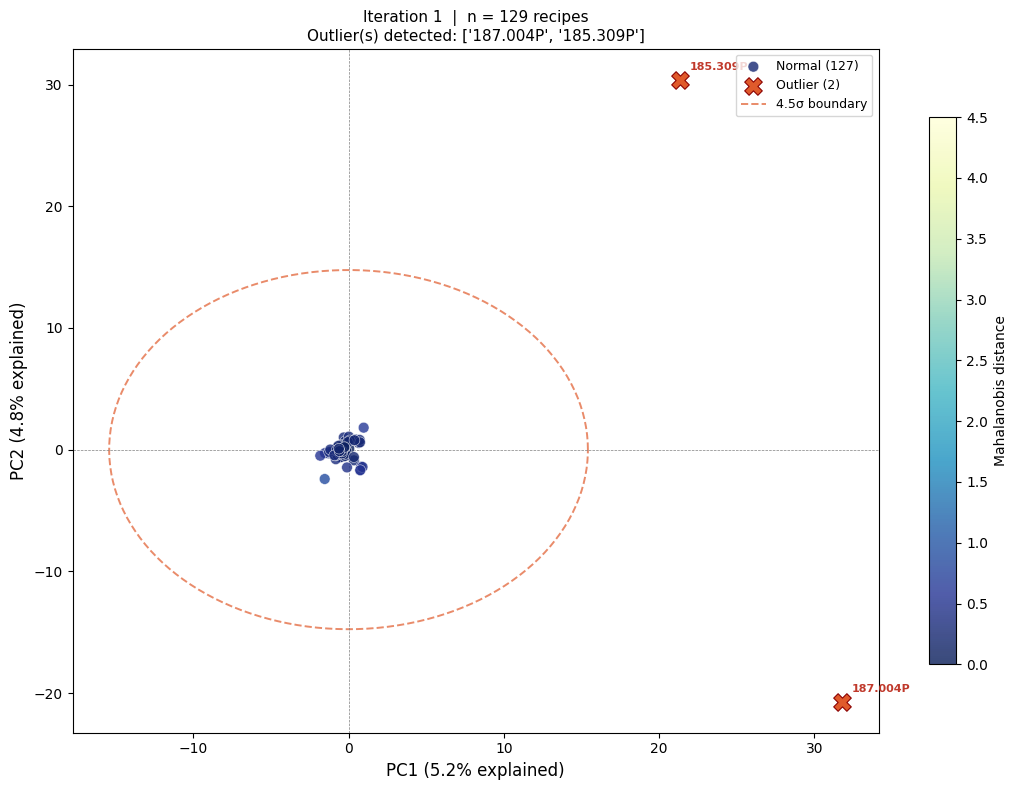

Saved: pca_v2_noOT_iter01.png
Iteration 1: removing 2 outlier(s): ['187.004P', '185.309P']


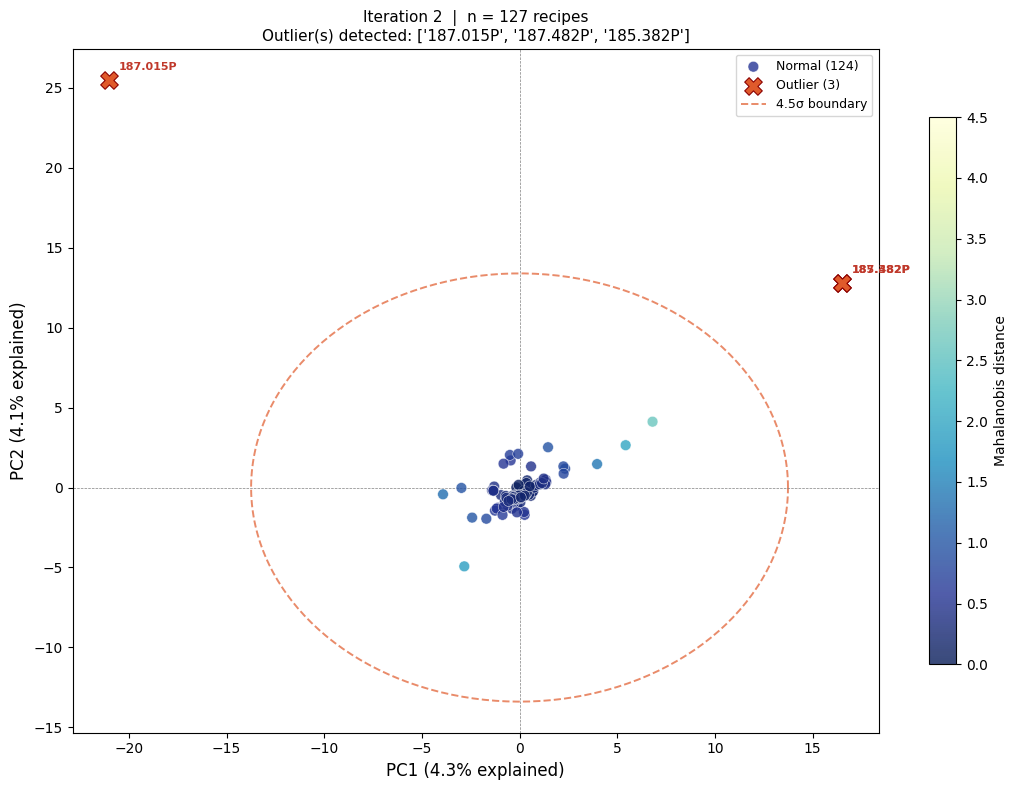

Saved: pca_v2_noOT_iter02.png
Iteration 2: removing 3 outlier(s): ['187.015P', '187.482P', '185.382P']


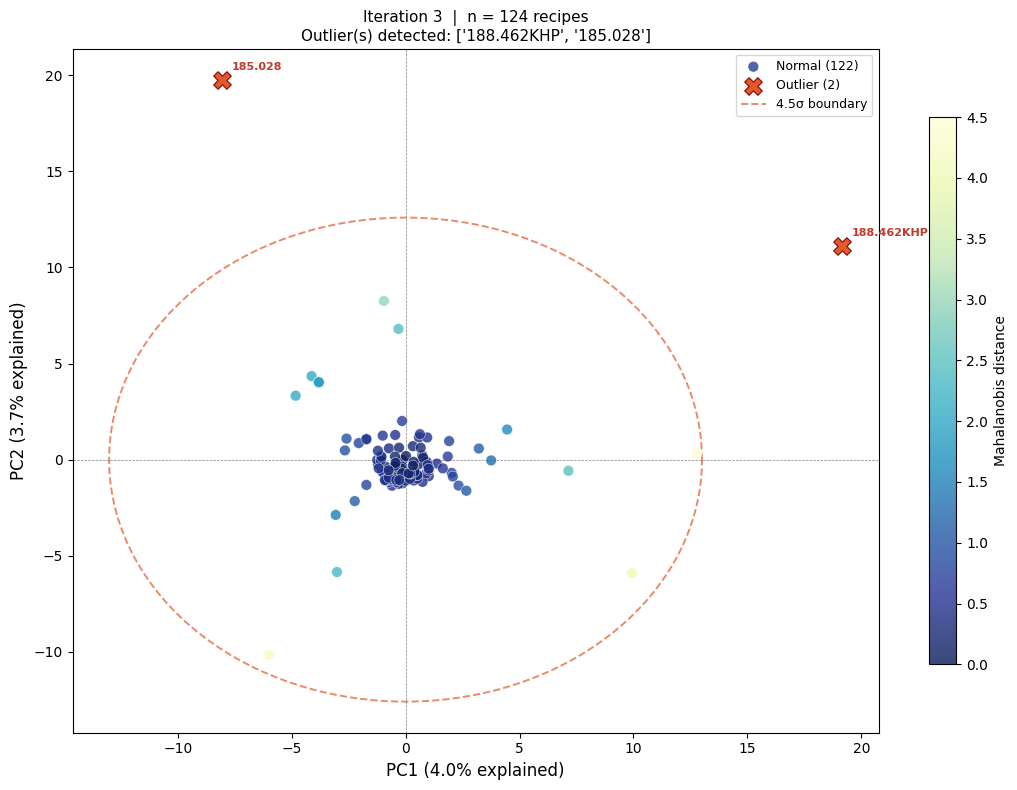

Saved: pca_v2_noOT_iter03.png
Iteration 3: removing 2 outlier(s): ['188.462KHP', '185.028']


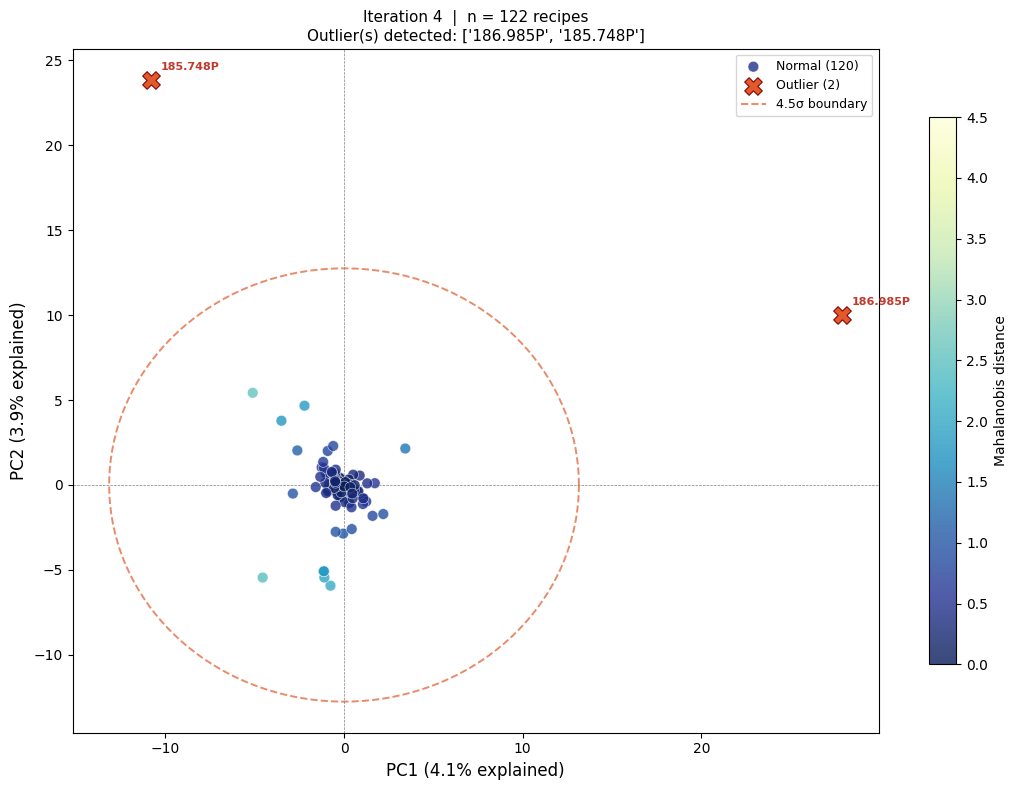

Saved: pca_v2_noOT_iter04.png
Iteration 4: removing 2 outlier(s): ['186.985P', '185.748P']


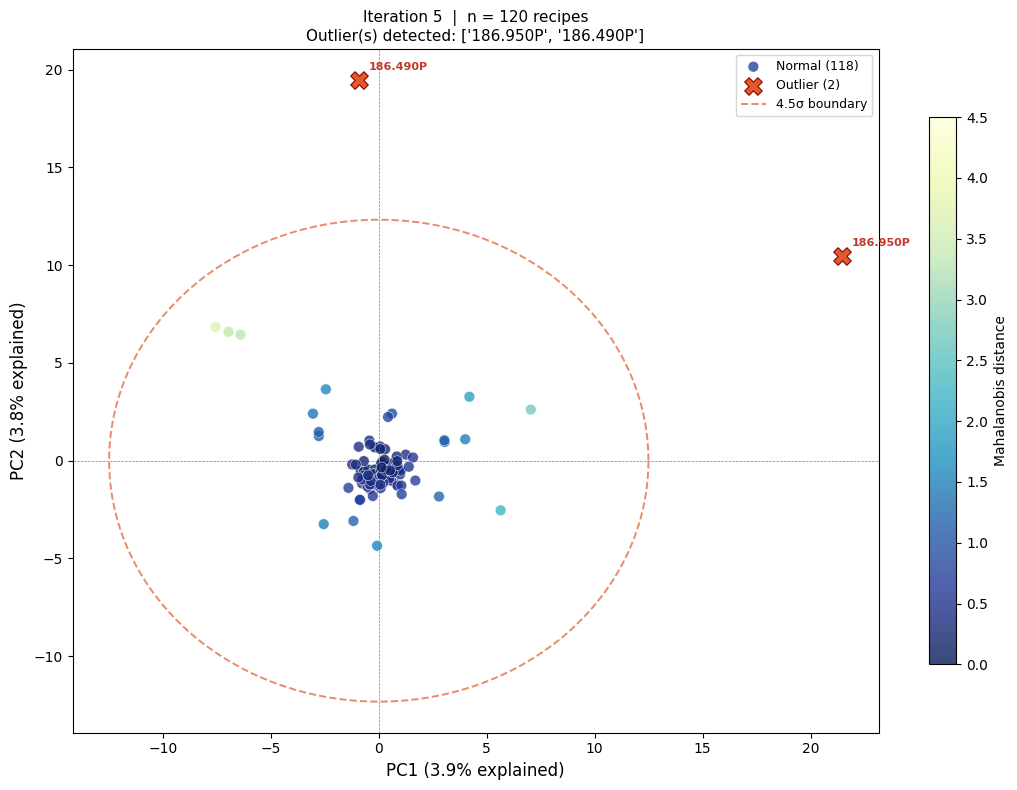

Saved: pca_v2_noOT_iter05.png
Iteration 5: removing 2 outlier(s): ['186.950P', '186.490P']


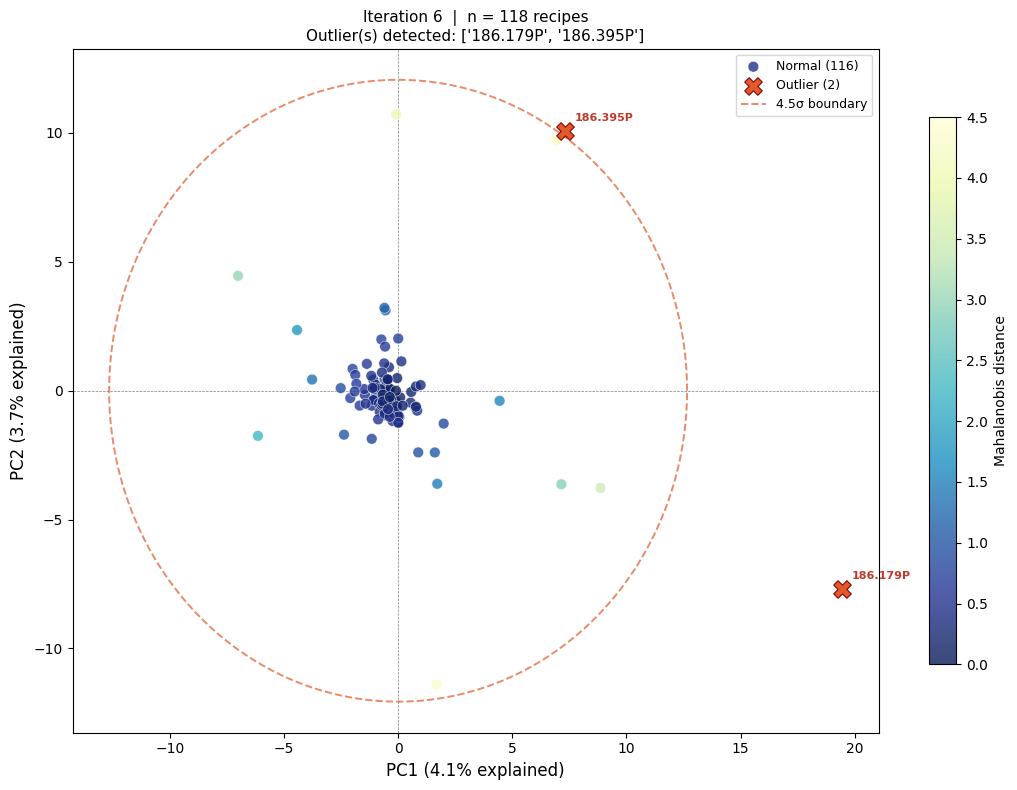

Saved: pca_v2_noOT_iter06.png
Iteration 6: removing 2 outlier(s): ['186.179P', '186.395P']


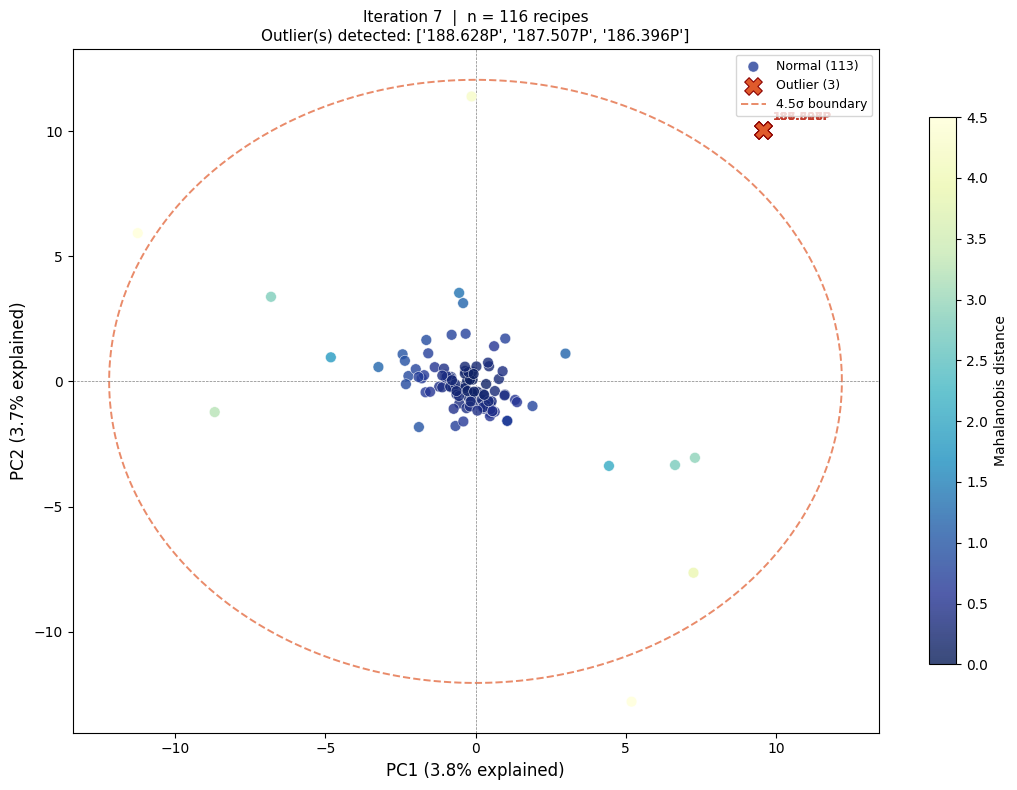

Saved: pca_v2_noOT_iter07.png
Iteration 7: removing 3 outlier(s): ['188.628P', '187.507P', '186.396P']


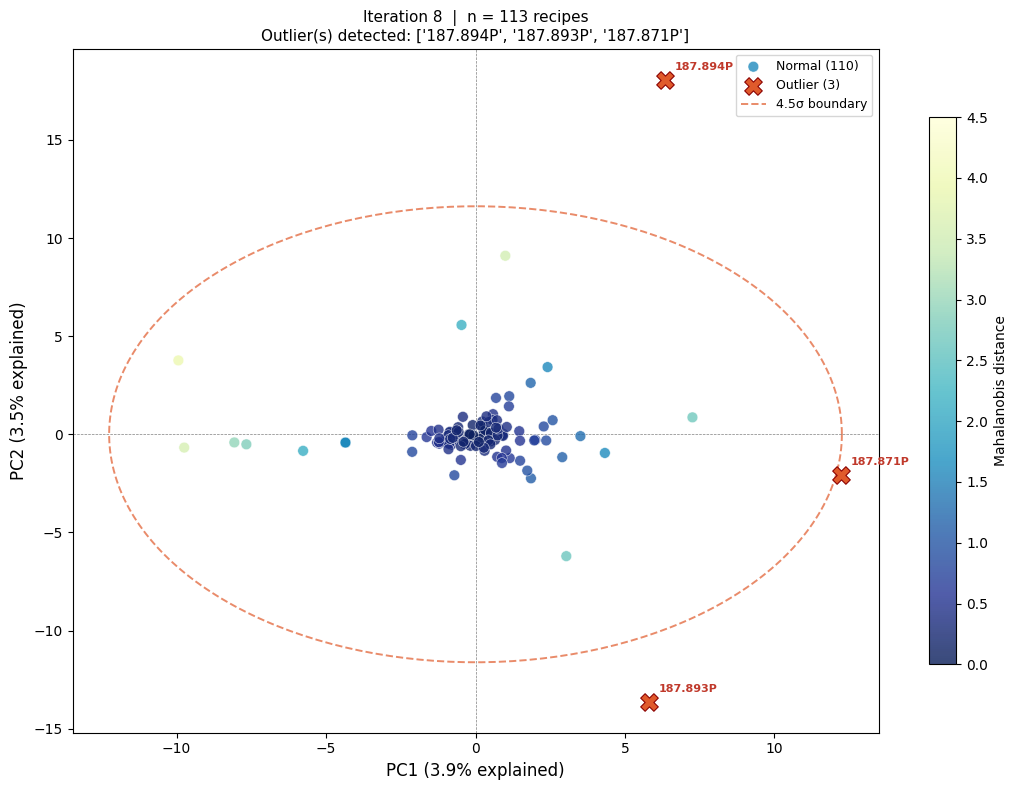

Saved: pca_v2_noOT_iter08.png
Iteration 8: removing 3 outlier(s): ['187.894P', '187.893P', '187.871P']


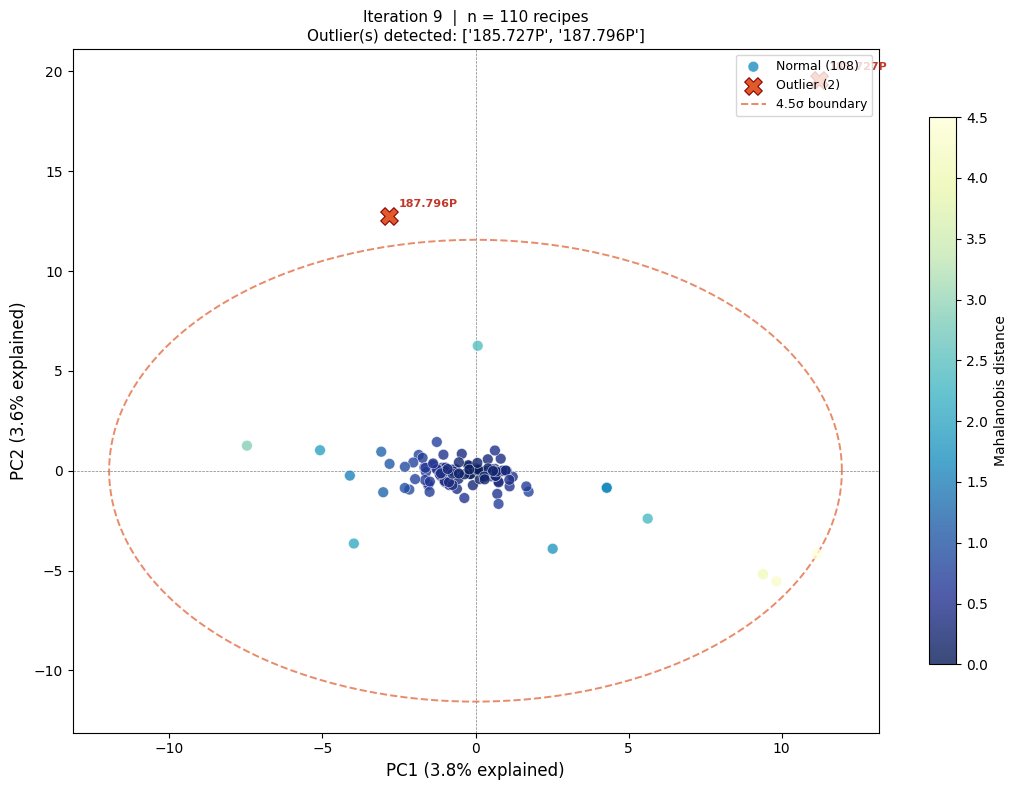

Saved: pca_v2_noOT_iter09.png
Iteration 9: removing 2 outlier(s): ['185.727P', '187.796P']


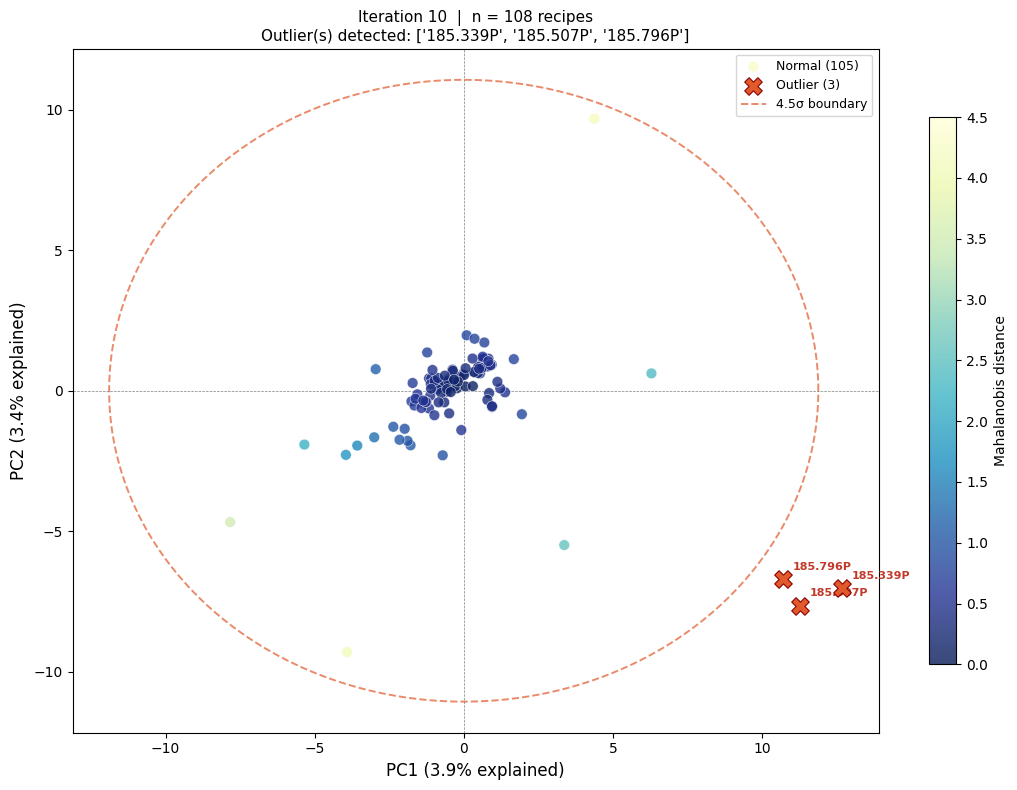

Saved: pca_v2_noOT_iter10.png
Iteration 10: removing 3 outlier(s): ['185.339P', '185.507P', '185.796P']


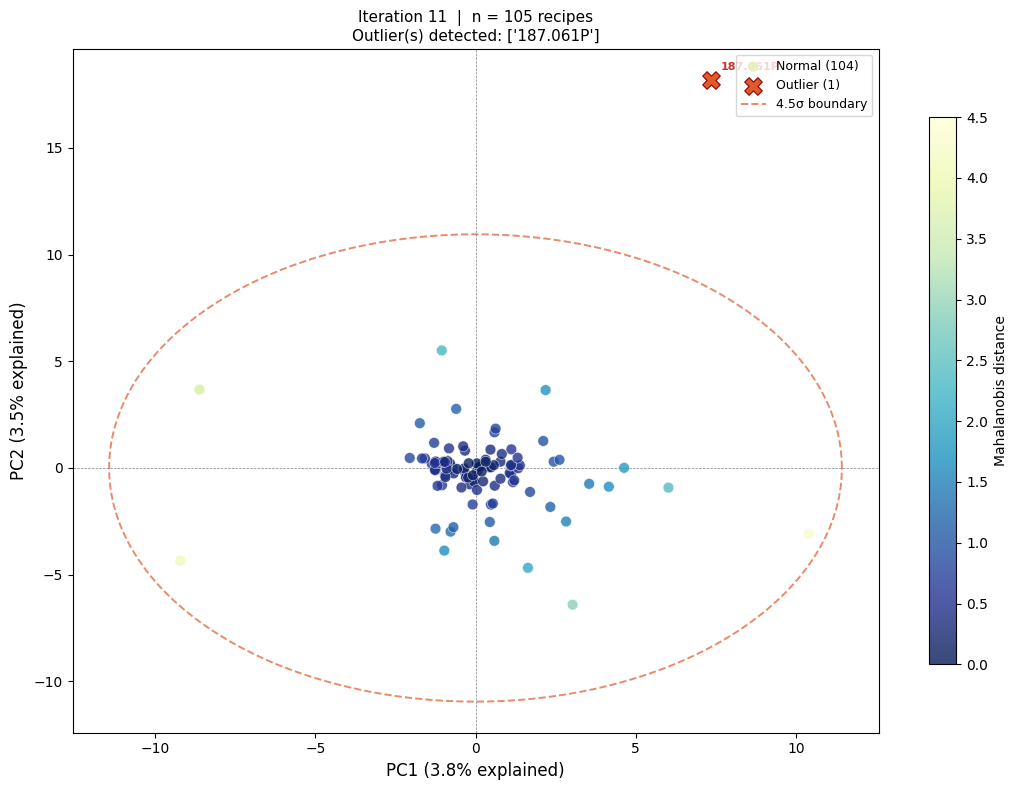

Saved: pca_v2_noOT_iter11.png
Iteration 11: removing 1 outlier(s): ['187.061P']


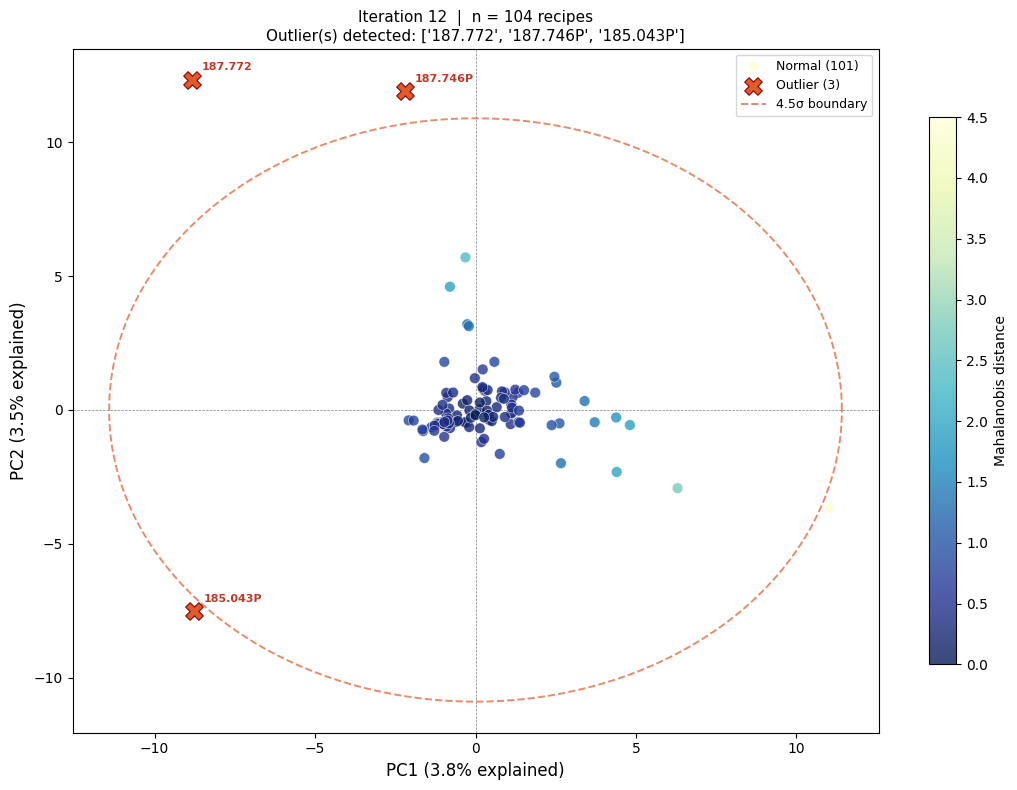

Saved: pca_v2_noOT_iter12.png
Iteration 12: removing 3 outlier(s): ['187.772', '187.746P', '185.043P']


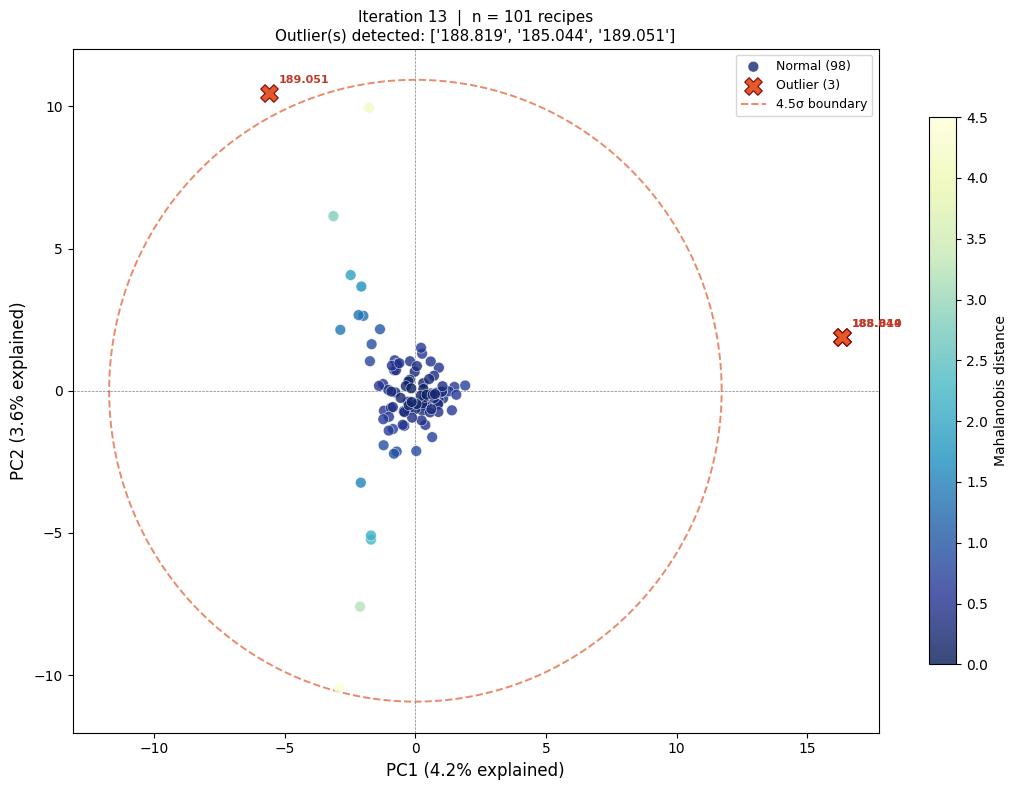

Saved: pca_v2_noOT_iter13.png
Iteration 13: removing 3 outlier(s): ['188.819', '185.044', '189.051']


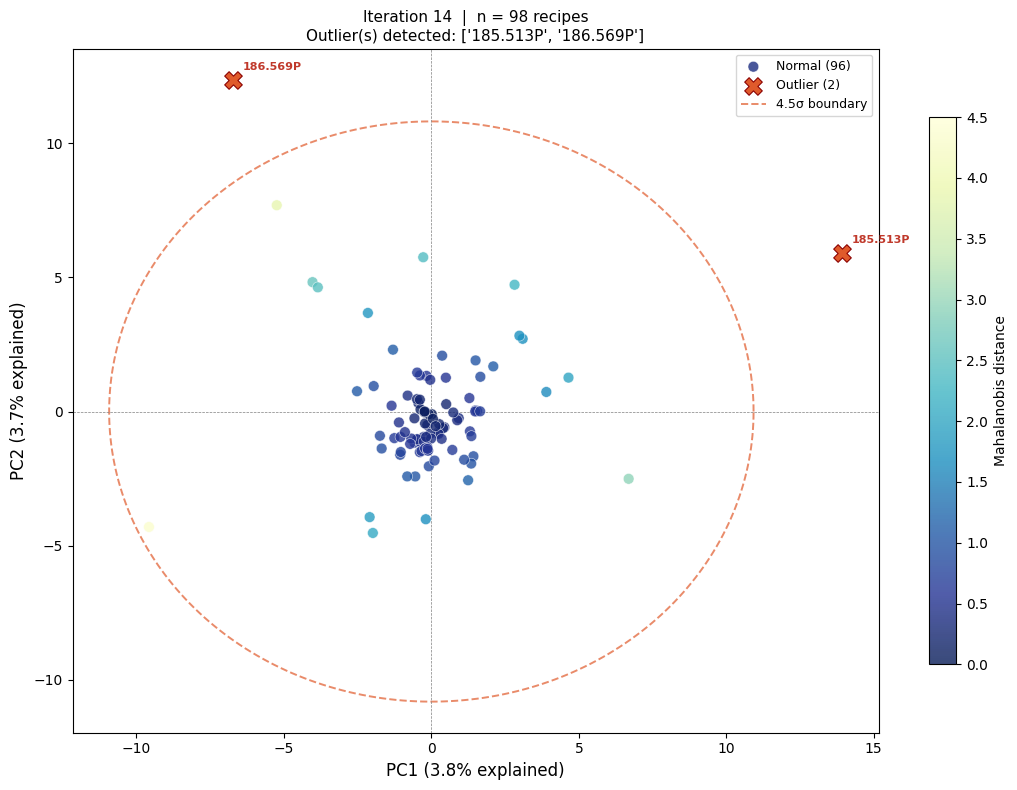

Saved: pca_v2_noOT_iter14.png
Iteration 14: removing 2 outlier(s): ['185.513P', '186.569P']


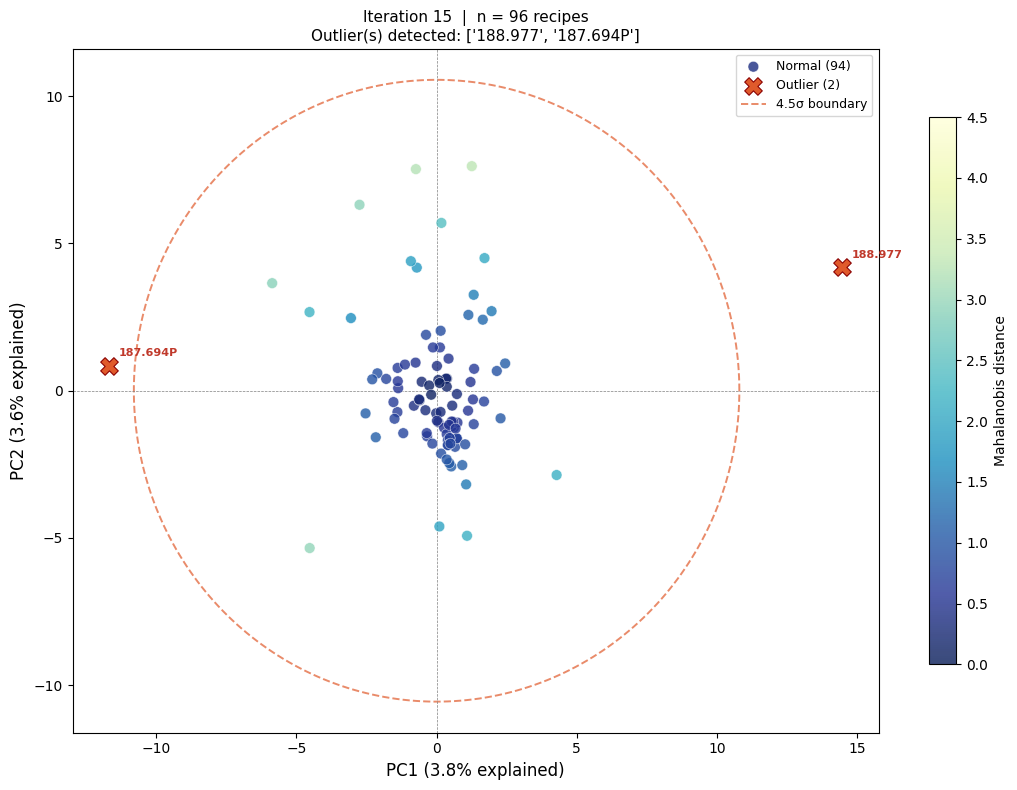

Saved: pca_v2_noOT_iter15.png
Iteration 15: removing 2 outlier(s): ['188.977', '187.694P']


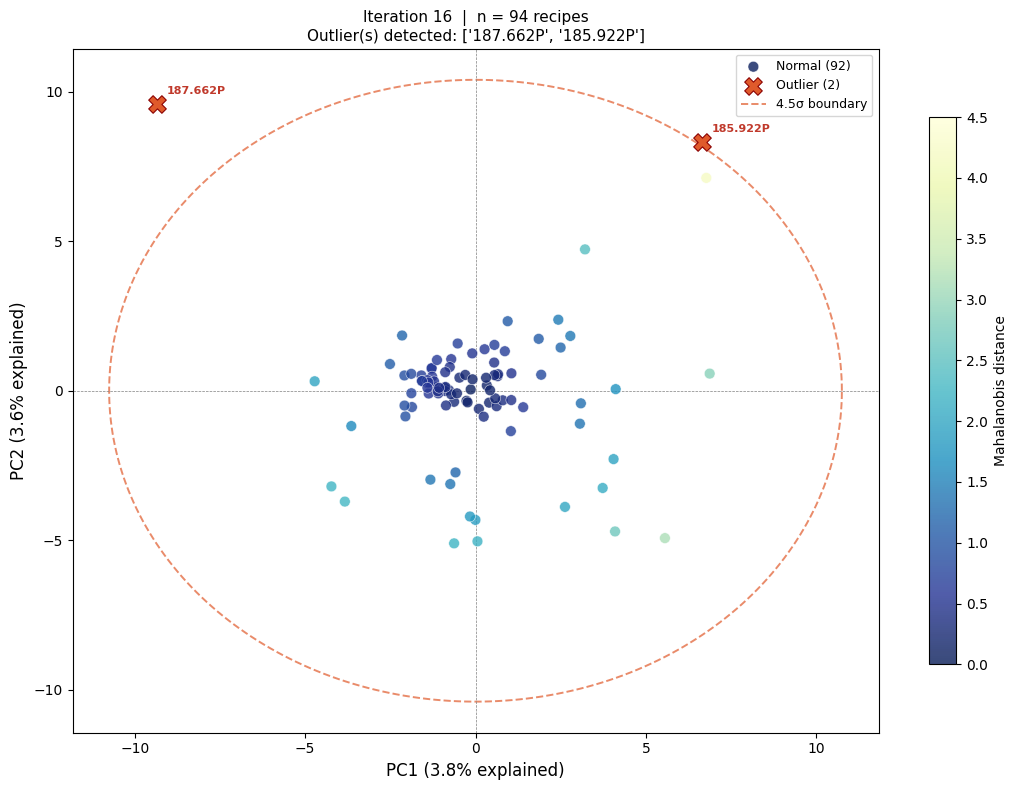

Saved: pca_v2_noOT_iter16.png
Iteration 16: removing 2 outlier(s): ['187.662P', '185.922P']


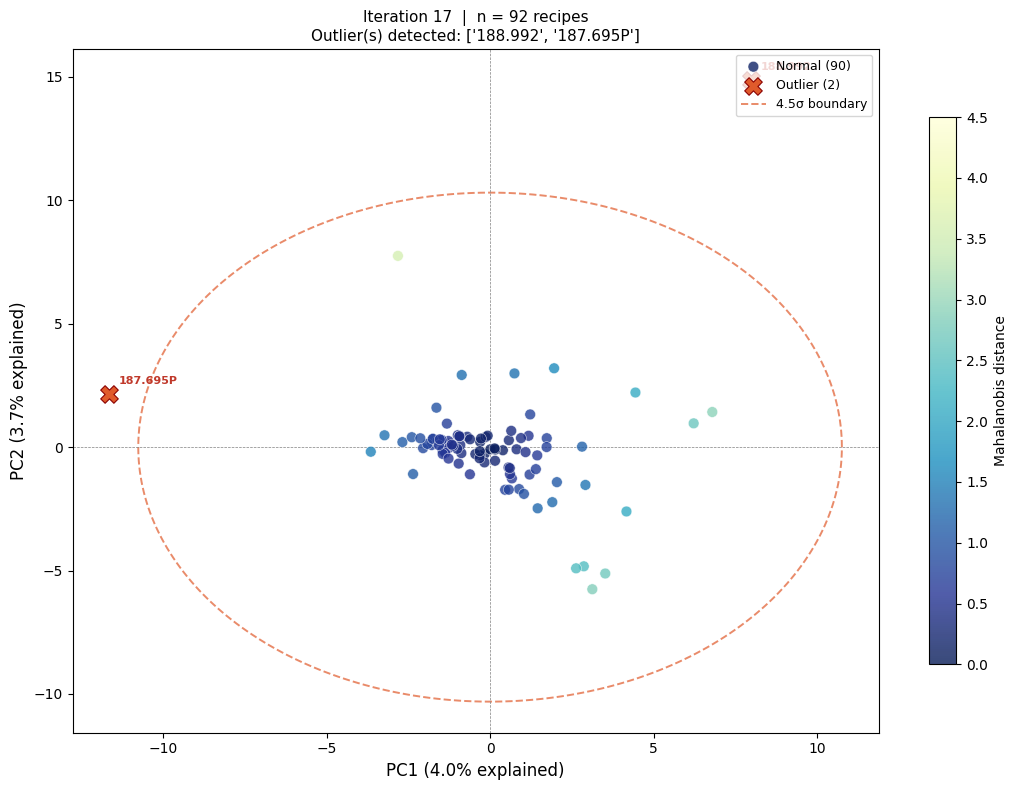

Saved: pca_v2_noOT_iter17.png
Iteration 17: removing 2 outlier(s): ['188.992', '187.695P']


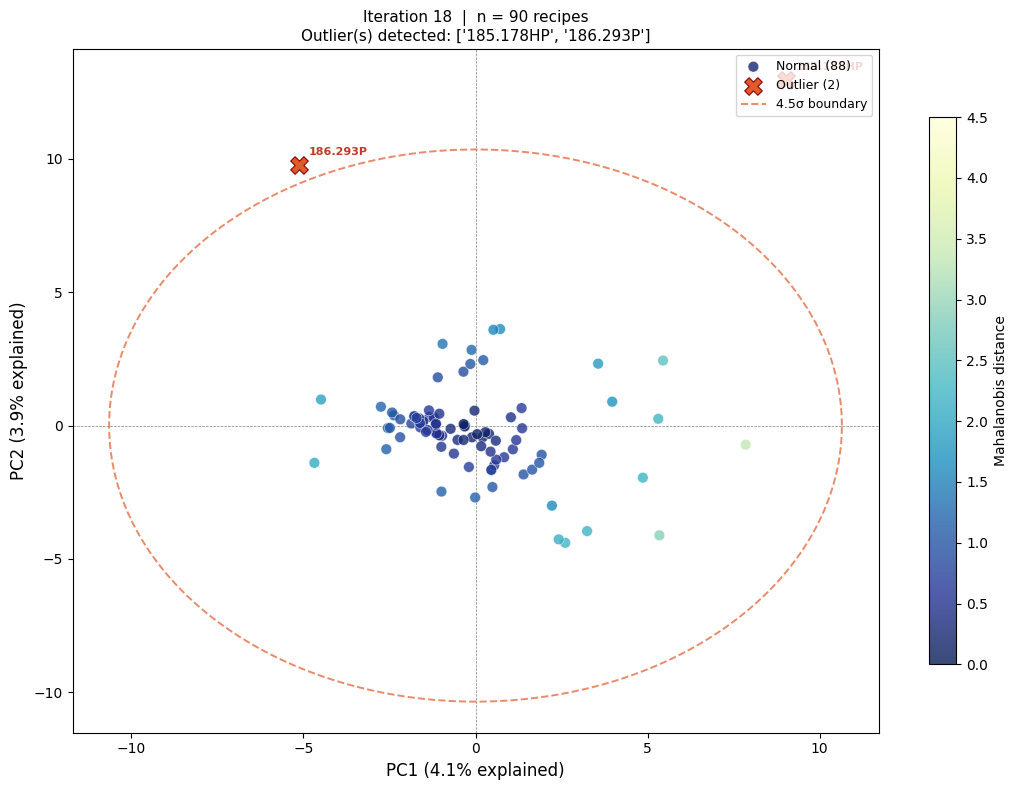

Saved: pca_v2_noOT_iter18.png
Iteration 18: removing 2 outlier(s): ['185.178HP', '186.293P']


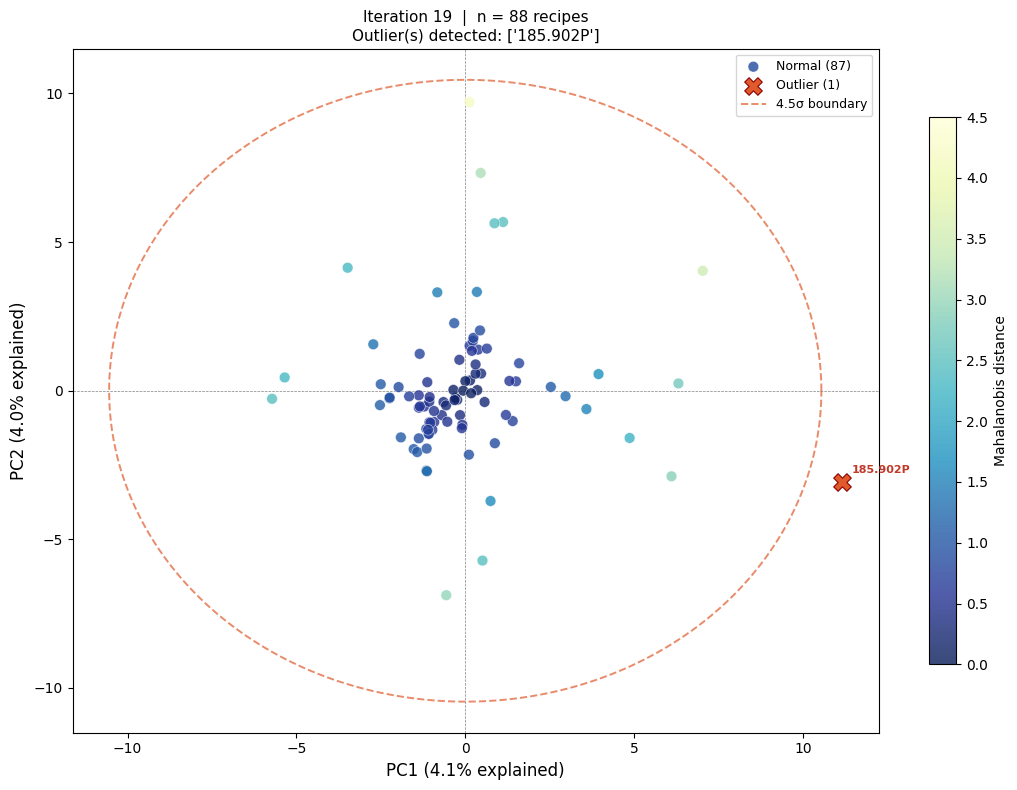

Saved: pca_v2_noOT_iter19.png
Iteration 19: removing 1 outlier(s): ['185.902P']


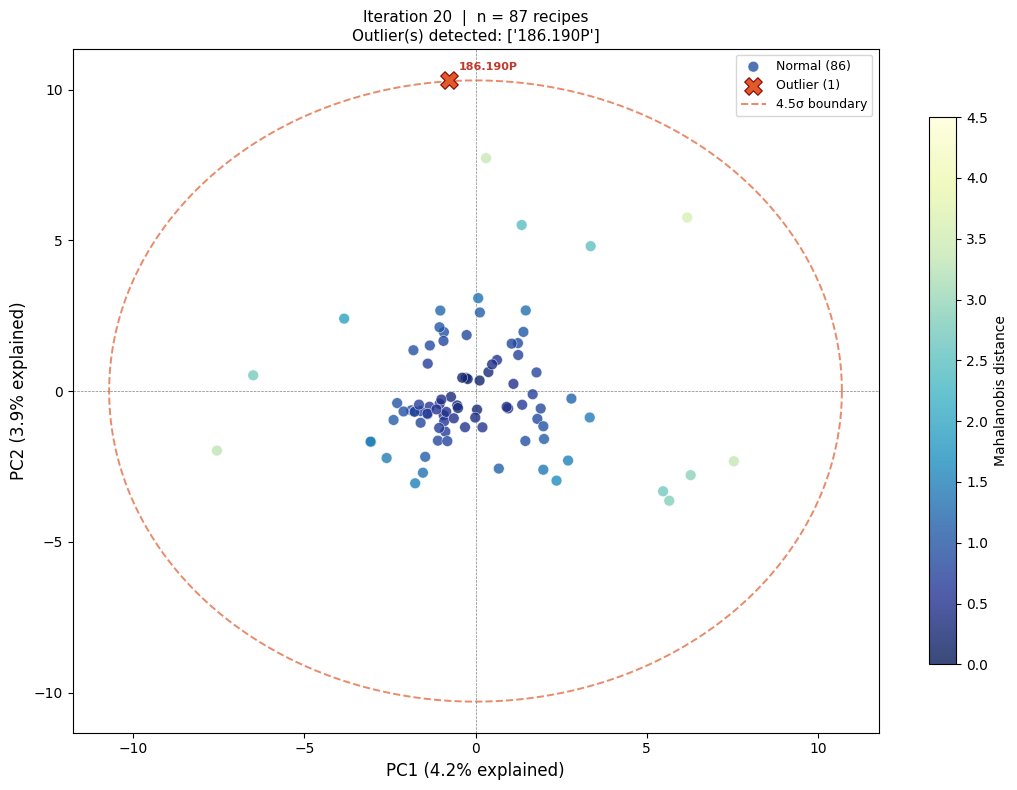

Saved: pca_v2_noOT_iter20.png
Iteration 20: removing 1 outlier(s): ['186.190P']

⚠ Maximum 20 iterations reached — stopping.
  Remaining dataset: 86 recipes

Total removed: 43 recipe(s)
Removed list: [(1, '187.004P'), (1, '185.309P'), (2, '187.015P'), (2, '187.482P'), (2, '185.382P'), (3, '188.462KHP'), (3, '185.028'), (4, '186.985P'), (4, '185.748P'), (5, '186.950P'), (5, '186.490P'), (6, '186.179P'), (6, '186.395P'), (7, '188.628P'), (7, '187.507P'), (7, '186.396P'), (8, '187.894P'), (8, '187.893P'), (8, '187.871P'), (9, '185.727P'), (9, '187.796P'), (10, '185.339P'), (10, '185.507P'), (10, '185.796P'), (11, '187.061P'), (12, '187.772'), (12, '187.746P'), (12, '185.043P'), (13, '188.819'), (13, '185.044'), (13, '189.051'), (14, '185.513P'), (14, '186.569P'), (15, '188.977'), (15, '187.694P'), (16, '187.662P'), (16, '185.922P'), (17, '188.992'), (17, '187.695P'), (18, '185.178HP'), (18, '186.293P'), (19, '185.902P'), (20, '186.190P')]


In [7]:
MAX_ITER          = 20
Z_THRESH          = 4.5   # 2D Mahalanobis distance threshold (sigma)
MAX_REMOVE_PER_IT = 3     # max outliers removed per iteration

# Working copies
active_recipes = list(pivot_oav.index)
active_X       = X_oav.copy()

all_removed    = []   # [(iteration, rez_nr), ...]
iteration_log  = []   # metadata per iteration

# Will be set when the loop ends
final_scaler   = None
final_pca      = None
final_scores   = None
final_ev       = None
final_active_recipes = None
final_X_sc     = None

for it in range(1, MAX_ITER + 1):
    # ── Scale ─────────────────────────────────────────────────────────────
    scaler = StandardScaler()
    X_sc   = scaler.fit_transform(active_X)

    # ── PCA ───────────────────────────────────────────────────────────────
    n_comp = min(10, X_sc.shape[1], X_sc.shape[0] - 1)
    pca    = PCA(n_components=n_comp, random_state=42)
    scores = pca.fit_transform(X_sc)
    ev     = pca.explained_variance_ratio_ * 100

    # ── Outlier detection: 2D Mahalanobis in PC1-PC2 space ───────────────
    s1 = scores[:, 0]
    s2 = scores[:, 1]
    z1 = (s1 - s1.mean()) / (s1.std() + 1e-12)
    z2 = (s2 - s2.mean()) / (s2.std() + 1e-12)
    mahal        = np.sqrt(z1**2 + z2**2)
    # Keep at most MAX_REMOVE_PER_IT extreme outliers per iteration
    cand_idx    = np.where(mahal > Z_THRESH)[0]
    # Sort candidates by distance (worst first) and cap
    cand_sorted = cand_idx[np.argsort(mahal[cand_idx])[::-1]][:MAX_REMOVE_PER_IT]
    outlier_idx = cand_sorted
    outlier_mask = np.zeros(len(active_recipes), dtype=bool)
    outlier_mask[outlier_idx] = True
    outlier_rez  = [active_recipes[i] for i in outlier_idx]

    # ── 3-sigma ellipse in score space ────────────────────────────────────
    theta   = np.linspace(0, 2 * np.pi, 300)
    ell_cx, ell_cy = s1.mean(), s2.mean()
    ell_ax, ell_ay = Z_THRESH * s1.std(), Z_THRESH * s2.std()
    ell_x = ell_cx + ell_ax * np.cos(theta)
    ell_y = ell_cy + ell_ay * np.sin(theta)

    # ── Plot ──────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(11, 8))

    # Color normal points by Mahalanobis distance (cool=close, warm=far)
    cmap   = plt.get_cmap('Blues')
    norm_d = plt.Normalize(vmin=0, vmax=Z_THRESH)
    non_out = ~outlier_mask
    sc = ax.scatter(
        s1[non_out], s2[non_out],
        c=mahal[non_out], cmap='YlGnBu_r', norm=norm_d,
        s=60, alpha=0.80, edgecolors='white', linewidths=0.4,
        label=f'Normal ({non_out.sum()})', zorder=3
    )
    plt.colorbar(sc, ax=ax, label='Mahalanobis distance', shrink=0.8)

    if len(outlier_idx):
        ax.scatter(
            s1[outlier_mask], s2[outlier_mask],
            c='#E05A2B', s=160, alpha=1.0, marker='X', zorder=5,
            edgecolors='#8B0000', linewidths=0.8,
            label=f'Outlier ({outlier_mask.sum()})'
        )
        for i in outlier_idx:
            ax.annotate(
                str(active_recipes[i]),
                (s1[i], s2[i]),
                xytext=(7, 7), textcoords='offset points',
                fontsize=8, color='#C0392B', fontweight='bold'
            )

    ax.plot(ell_x, ell_y, '--', color='#E05A2B', lw=1.4, alpha=0.7,
            label=f'{Z_THRESH:.1f}σ boundary')
    ax.axhline(0, color='grey', lw=0.5, ls='--')
    ax.axvline(0, color='grey', lw=0.5, ls='--')
    ax.set_xlabel(f'PC1 ({ev[0]:.1f}% explained)', fontsize=12)
    ax.set_ylabel(f'PC2 ({ev[1]:.1f}% explained)', fontsize=12)

    if outlier_rez:
        status = f'Outlier(s) detected: {outlier_rez}'
    else:
        status = 'No outliers — convergence reached ✓'

    ax.set_title(
        f'Iteration {it}  |  n = {len(active_recipes)} recipes\n{status}',
        fontsize=11
    )
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    fname = f'pca_v2_noOT_iter{it:02d}.png'
    fig.savefig(OUT_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

    iteration_log.append({
        'iteration': it,
        'n_recipes': len(active_recipes),
        'outliers':  outlier_rez,
        'n_outliers': len(outlier_rez),
        'ev_PC1':    round(ev[0], 1),
        'ev_PC2':    round(ev[1], 1),
        'ev_cum3':   round(sum(ev[:3]), 1),
    })

    # ── Store final-state variables ────────────────────────────────────────
    final_scaler         = scaler
    final_pca            = pca
    final_scores         = scores
    final_ev             = ev
    final_active_recipes = active_recipes.copy()
    final_X_sc           = X_sc

    if not outlier_rez:
        print(f'\n✓ Iteration {it}: No outliers — converged.')
        print(f'  Final clean dataset: {len(active_recipes)} recipes')
        break

    print(f'Iteration {it}: removing {len(outlier_rez)} outlier(s): {outlier_rez}')
    for r in outlier_rez:
        all_removed.append((it, r))

    keep           = ~outlier_mask
    active_recipes = [r for r, k in zip(active_recipes, keep) if k]
    active_X       = active_X[keep]

else:
    print(f'\n⚠ Maximum {MAX_ITER} iterations reached — stopping.')
    print(f'  Remaining dataset: {len(active_recipes)} recipes')

print(f'\nTotal removed: {len(all_removed)} recipe(s)')
print('Removed list:', all_removed)

In [8]:
# ── Iteration summary table ───────────────────────────────────────────────
iter_df = pd.DataFrame(iteration_log)
print('=== Iteration Log ===')
print(iter_df.to_string(index=False))

# Set up convenient aliases used by all subsequent sections
scaler_oav   = final_scaler
pca_oav      = final_pca
scores_oav   = final_scores
ev           = final_ev
recipes_oav  = final_active_recipes
X_oav_scaled = final_X_sc
loadings     = pca_oav.components_
cas_labels   = list(pivot_oav.columns)
cas_name     = df.groupby('CAS-Nr.')['Name'].first().to_dict()

# Final pivot (only clean recipes)
final_pivot  = pivot_oav.loc[recipes_oav]

print(f'\nFinal dataset: {len(recipes_oav)} recipes × {final_pivot.shape[1]} CAS')
print(f'Explained variance: PC1={ev[0]:.1f}%  PC2={ev[1]:.1f}%  PC3={ev[2]:.1f}%')

=== Iteration Log ===
 iteration  n_recipes                       outliers  n_outliers  ev_PC1  ev_PC2  ev_cum3
         1        129           [187.004P, 185.309P]           2     5.2     4.8     14.0
         2        127 [187.015P, 187.482P, 185.382P]           3     4.3     4.1     12.0
         3        124          [188.462KHP, 185.028]           2     4.0     3.7     11.3
         4        122           [186.985P, 185.748P]           2     4.1     3.9     11.7
         5        120           [186.950P, 186.490P]           2     3.9     3.8     11.2
         6        118           [186.179P, 186.395P]           2     4.1     3.7     11.3
         7        116 [188.628P, 187.507P, 186.396P]           3     3.8     3.7     10.9
         8        113 [187.894P, 187.893P, 187.871P]           3     3.9     3.5     10.8
         9        110           [185.727P, 187.796P]           2     3.8     3.6     10.7
        10        108 [185.339P, 185.507P, 185.796P]           3     3.9     3

## 3 · Final PCA Analysis (Clean Dataset)

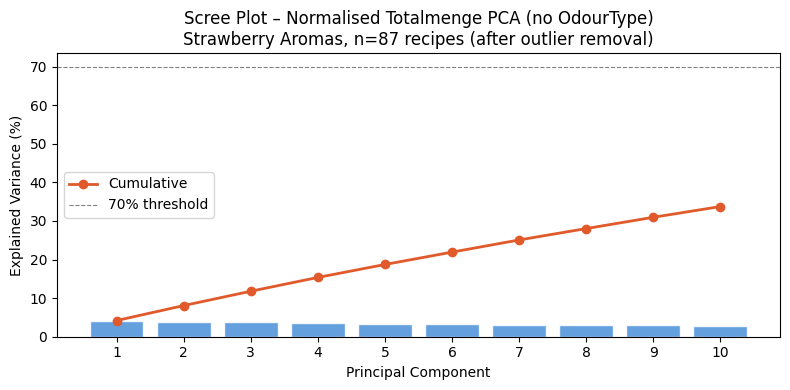

Saved: pca_v2_noOT_scree.png


In [9]:
# ── Scree plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(ev)+1), ev, color='#4A90D9', alpha=0.85, edgecolor='white')
ax.plot(range(1, len(ev)+1), np.cumsum(ev), 'o-', color='#E05A2B', lw=2, label='Cumulative')
ax.axhline(70, ls='--', color='grey', lw=0.8, label='70% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title(
    f'Scree Plot – Normalised Totalmenge PCA (no OdourType)\n'
    f'Strawberry Aromas, n={len(recipes_oav)} recipes (after outlier removal)'
)
ax.set_xticks(range(1, len(ev)+1))
ax.legend()
plt.tight_layout()
fig.savefig(OUT_DIR / 'pca_v2_noOT_scree.png', dpi=150)
plt.show()
print('Saved: pca_v2_noOT_scree.png')

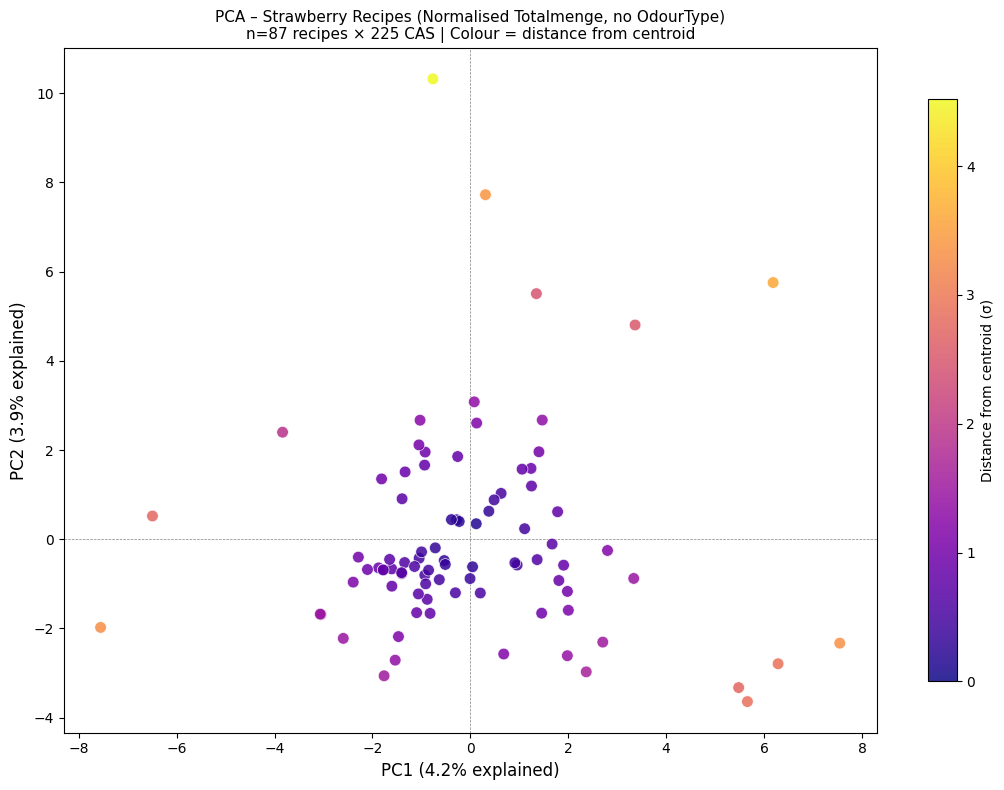

Saved: pca_v2_noOT_pc1pc2.png


In [10]:
# ── PC1 vs PC2 scatter – coloured by Mahalanobis distance from centroid ─────
s1_f  = scores_oav[:, 0]
s2_f  = scores_oav[:, 1]
z1_f  = (s1_f - s1_f.mean()) / (s1_f.std() + 1e-12)
z2_f  = (s2_f - s2_f.mean()) / (s2_f.std() + 1e-12)
dist_f = np.sqrt(z1_f**2 + z2_f**2)

fig, ax = plt.subplots(figsize=(11, 8))
sc = ax.scatter(
    s1_f, s2_f,
    c=dist_f, cmap='plasma', vmin=0, vmax=dist_f.max(),
    s=70, alpha=0.85, edgecolors='white', linewidths=0.5, zorder=3
)
plt.colorbar(sc, ax=ax, label='Distance from centroid (σ)', shrink=0.85)

ax.axhline(0, color='grey', lw=0.5, ls='--')
ax.axvline(0, color='grey', lw=0.5, ls='--')
ax.set_xlabel(f'PC1 ({ev[0]:.1f}% explained)', fontsize=12)
ax.set_ylabel(f'PC2 ({ev[1]:.1f}% explained)', fontsize=12)
ax.set_title(
    f'PCA – Strawberry Recipes (Normalised Totalmenge, no OdourType)\n'
    f'n={len(recipes_oav)} recipes × {final_pivot.shape[1]} CAS | '
    f'Colour = distance from centroid',
    fontsize=11
)
plt.tight_layout()
fig.savefig(OUT_DIR / 'pca_v2_noOT_pc1pc2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pca_v2_noOT_pc1pc2.png')

## 4 · Biplot – Top Ingredient Loadings

In [11]:
N_ARROWS  = 12
importance = np.sqrt(loadings[0]**2 + loadings[1]**2)
top_idx    = np.argsort(importance)[::-1][:N_ARROWS]

print(f'Top {N_ARROWS} ingredients driving PC1+PC2:')
for i in top_idx:
    cas  = cas_labels[i]
    name = cas_name.get(cas, cas)
    print(f'  {cas:15s} {name[:45]:45s}  L1={loadings[0,i]:+.3f}  L2={loadings[1,i]:+.3f}')

Top 12 ingredients driving PC1+PC2:
  928-96-1        cis-3-Hexen-1-ol Halal Kosher                  L1=+0.065  L2=+0.310
  706-14-9        gamma-Decalacton Kosher Halal                  L1=+0.163  L2=+0.266
  105-54-4        Ethylbutyrat Kosher Halal                      L1=+0.263  L2=-0.126
  98-01-1         Furfural Halal                                 L1=-0.006  L2=+0.263
  2305-21-7       trans-2-Hexen-1-ol Halal Kosher                L1=-0.004  L2=+0.257
  100-52-7        Benzaldehyd Kosher Halal                       L1=+0.057  L2=+0.246
  116-53-0        2-Methylbuttersäure Halal Kosher               L1=+0.233  L2=+0.064
  123-92-2        Isoamylacetat Halal                            L1=+0.225  L2=-0.041
  142-62-1        Hexansäure kräftig                             L1=+0.224  L2=-0.015
  7452-79-1       Ethyl-2-methylbutyrat Kosher Halal             L1=+0.216  L2=-0.043
  78-83-1         Isobutanol Halal                               L1=+0.189  L2=-0.112
  10544-63-5      

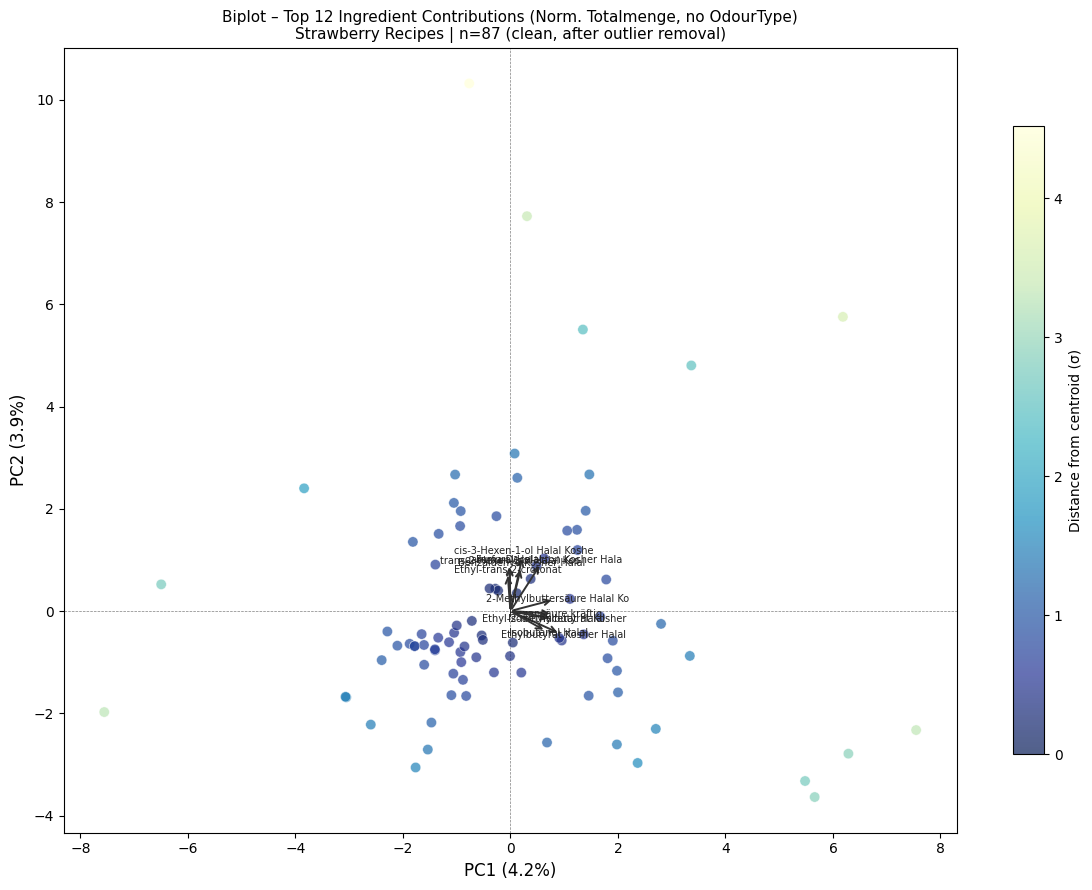

Saved: pca_v2_noOT_biplot.png


In [12]:
# ── Biplot ───────────────────────────────────────────────────────────────────
SCALE = 3.5

fig, ax = plt.subplots(figsize=(12, 9))

# Scatter recipes (coloured by Mahalanobis distance)
sc = ax.scatter(
    scores_oav[:, 0], scores_oav[:, 1],
    c=dist_f, cmap='YlGnBu_r', vmin=0, vmax=dist_f.max(),
    s=55, alpha=0.70, edgecolors='white', linewidths=0.4, zorder=3
)
plt.colorbar(sc, ax=ax, label='Distance from centroid (σ)', shrink=0.8)

# Arrow overlays for top ingredients
for i in top_idx:
    cas   = cas_labels[i]
    name  = cas_name.get(cas, cas)
    short = name.split(',')[0][:28]
    lx, ly = loadings[0, i] * SCALE, loadings[1, i] * SCALE
    ax.annotate('', xy=(lx, ly), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#333333', lw=1.4))
    ax.text(lx * 1.08, ly * 1.08, short, fontsize=7, color='#222222',
            ha='center', va='center')

ax.axhline(0, color='grey', lw=0.5, ls='--')
ax.axvline(0, color='grey', lw=0.5, ls='--')
ax.set_xlabel(f'PC1 ({ev[0]:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({ev[1]:.1f}%)', fontsize=12)
ax.set_title(
    f'Biplot – Top {N_ARROWS} Ingredient Contributions (Norm. Totalmenge, no OdourType)\n'
    f'Strawberry Recipes | n={len(recipes_oav)} (clean, after outlier removal)',
    fontsize=11
)
plt.tight_layout()
fig.savefig(OUT_DIR / 'pca_v2_noOT_biplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pca_v2_noOT_biplot.png')

## 5 · PC1–PC3 Dashboard (3-Panel)

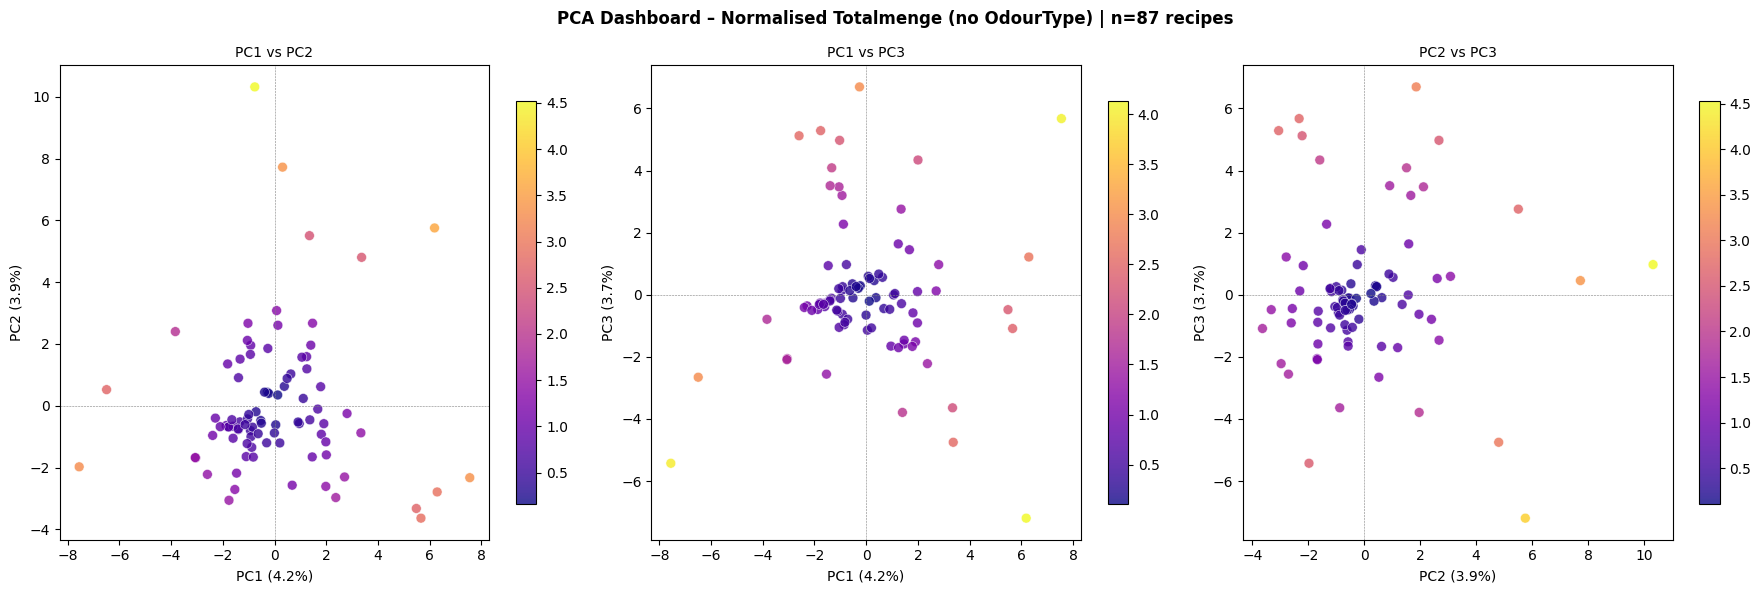

Saved: pca_v2_noOT_dashboard_pc123.png


In [13]:
# ── PC1 vs PC2, PC1 vs PC3, PC2 vs PC3 ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
pairs = [(0, 1), (0, 2), (1, 2)]

for ax, (i, j) in zip(axes, pairs):
    si = scores_oav[:, i]
    sj = scores_oav[:, j]
    zi = (si - si.mean()) / (si.std() + 1e-12)
    zj = (sj - sj.mean()) / (sj.std() + 1e-12)
    d_ij = np.sqrt(zi**2 + zj**2)
    sc = ax.scatter(
        si, sj,
        c=d_ij, cmap='plasma',
        s=50, alpha=0.80, edgecolors='white', linewidths=0.4
    )
    plt.colorbar(sc, ax=ax, shrink=0.85)
    ax.axhline(0, color='grey', lw=0.4, ls='--')
    ax.axvline(0, color='grey', lw=0.4, ls='--')
    ax.set_xlabel(f'PC{i+1} ({ev[i]:.1f}%)', fontsize=10)
    ax.set_ylabel(f'PC{j+1} ({ev[j]:.1f}%)', fontsize=10)
    ax.set_title(f'PC{i+1} vs PC{j+1}', fontsize=10)

fig.suptitle(
    f'PCA Dashboard – Normalised Totalmenge (no OdourType) | n={len(recipes_oav)} recipes',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
fig.savefig(OUT_DIR / 'pca_v2_noOT_dashboard_pc123.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pca_v2_noOT_dashboard_pc123.png')

## 6 · Loading Heatmap – Which Ingredients Drive Which Components

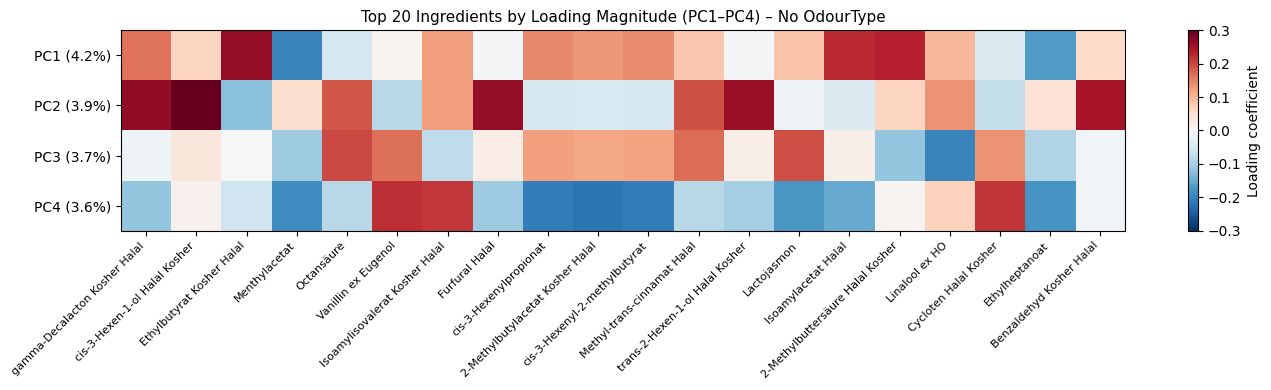

Saved: pca_v2_noOT_loading_heatmap.png


In [14]:
N_TOP = 20
N_PC  = min(4, pca_oav.n_components_)

importance_4 = np.sqrt((loadings[:N_PC]**2).sum(axis=0))
top20_idx    = np.argsort(importance_4)[::-1][:N_TOP]

top20_cas   = [cas_labels[i] for i in top20_idx]
top20_names = [cas_name.get(c, c).split(',')[0][:35] for c in top20_cas]
loading_mat = loadings[:N_PC][:, top20_idx]

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(loading_mat, aspect='auto', cmap='RdBu_r', vmin=-0.3, vmax=0.3)
ax.set_xticks(range(N_TOP))
ax.set_xticklabels(top20_names, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(N_PC))
ax.set_yticklabels([f'PC{k+1} ({ev[k]:.1f}%)' for k in range(N_PC)], fontsize=10)
plt.colorbar(im, ax=ax, label='Loading coefficient')
ax.set_title(f'Top {N_TOP} Ingredients by Loading Magnitude (PC1–PC{N_PC}) – No OdourType', fontsize=11)
plt.tight_layout()
fig.savefig(OUT_DIR / 'pca_v2_noOT_loading_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pca_v2_noOT_loading_heatmap.png')

## 7 · Recipe Scores Table

In [15]:
scores_df = pd.DataFrame(
    scores_oav[:, :5],
    index=pd.Index(recipes_oav, name='Rez.-Nr.'),
    columns=[f'PC{i+1}' for i in range(5)]
)
# Add Mahalanobis distance to centroid (PC1-PC2)
scores_df['Mahal_dist'] = dist_f.round(3)

print('PCA Scores (first 15 recipes):')
print(scores_df.head(15).round(3).to_string())

scores_df.to_csv(OUT_DIR / 'pca_v2_noOT_scores.csv')
print('\nFull table saved: pca_v2_noOT_scores.csv')

PCA Scores (first 15 recipes):
            PC1    PC2    PC3    PC4    PC5  Mahal_dist
Rez.-Nr.                                               
185.046  -0.924  1.956 -0.628  0.183 -1.798       0.938
185.086  -0.931 -0.803  0.148  0.534 -0.467       0.526
185.090P -1.604 -1.051 -0.380 -0.027 -0.421       0.816
185.091  -6.495  0.522 -2.656 -5.055  4.134       2.740
185.133  -3.054 -1.687 -2.058 -2.023  1.264       1.480
185.237H -0.534 -0.477  0.353  0.641 -0.070       0.306
185.239  -0.935  1.663  3.200 -1.066 -1.211       0.826
185.267   0.045 -0.617 -1.141 -0.287 -0.684       0.270
185.291  -1.343 -0.522 -0.111  0.099 -0.391       0.609
185.294  -0.513 -0.564 -0.101  1.170  0.299       0.327
185.314  -0.717 -0.193 -0.786  0.748 -0.170       0.313
185.321   1.239  1.589  1.638 -1.027 -0.680       0.868
185.471   5.660 -3.639 -1.087 -2.170 -1.169       2.861
185.514  -7.555 -1.976 -5.427 -6.271  6.225       3.291
185.578P  2.705 -2.305  0.123  2.222  3.407       1.519

Full table saved

## 8 · Outlier Removal Summary

Complete log of which recipes were removed in which iteration and why.

In [16]:
print('=== Outlier Removal Summary ===')
print(f'Total iterations run  : {len(iteration_log)}')
print(f'Total recipes removed : {len(all_removed)}')
print(f'Starting recipes      : {len(pivot_oav)}')
print(f'Final clean recipes   : {len(recipes_oav)}')
print()

if all_removed:
    print(f'  {"Iteration":>9}  {"Recipe":>12}')
    print(f'  {"─"*9}  {"─"*12}')
    for it_n, rez in all_removed:
        print(f'  {it_n:>9}  {rez:>12}')
else:
    print('  No recipes were removed (data was already harmonious).')

print()
print('=== Per-Iteration Detail ===')
for row in iteration_log:
    outliers_str = ', '.join(row['outliers']) if row['outliers'] else 'none'
    print(f"  Iter {row['iteration']:>2}: {row['n_recipes']:>3} recipes  "
          f"PC1={row['ev_PC1']:>4.1f}%  PC2={row['ev_PC2']:>4.1f}%  "
          f"Outliers: {outliers_str}")

=== Outlier Removal Summary ===
Total iterations run  : 20
Total recipes removed : 43
Starting recipes      : 129
Final clean recipes   : 87

  Iteration        Recipe
  ─────────  ────────────
          1      187.004P
          1      185.309P
          2      187.015P
          2      187.482P
          2      185.382P
          3    188.462KHP
          3       185.028
          4      186.985P
          4      185.748P
          5      186.950P
          5      186.490P
          6      186.179P
          6      186.395P
          7      188.628P
          7      187.507P
          7      186.396P
          8      187.894P
          8      187.893P
          8      187.871P
          9      185.727P
          9      187.796P
         10      185.339P
         10      185.507P
         10      185.796P
         11      187.061P
         12       187.772
         12      187.746P
         12      185.043P
         13       188.819
         13       185.044
         13       189.051


## Summary

| | Value |
|---|---|
| Version | v2 - without threshold, without OdourType |
| Pipeline | Remove ignore list → Normalise per recipe → Iterative PCA + outlier removal |
| Features | CAS-level normalised Totalmenge |
| OdourType | Not used |
| Log transform | None |
| Outlier threshold | 3σ Mahalanobis (2D PC1-PC2) |
| Max iterations | 20 |
| Outputs | `outputs/pca_v2_noOT_*` |

In [17]:
# ── Pre-compute full contribution tensor: (n_recipes, n_pc, n_cas) ──────────
N_PC_ATTR = 4
contrib = X_oav_scaled[:, np.newaxis, :] * loadings[np.newaxis, :N_PC_ATTR, :]  # (R, K, I)

recipe_idx_map = {r: idx for idx, r in enumerate(recipes_oav)}

print(f'Contribution tensor shape: {contrib.shape}  (recipes × PCs × ingredients)')
print('Ready for recipe lookup.')

Contribution tensor shape: (87, 4, 225)  (recipes × PCs × ingredients)
Ready for recipe lookup.


In [18]:
def explain_recipe(rez_nr, n_top=8, plot=True):
    if rez_nr not in recipe_idx_map:
        print(f'Recipe {rez_nr!r} not found in clean dataset.')
        print('Available (first 10):', sorted(recipe_idx_map.keys())[:10])
        return

    r_idx    = recipe_idx_map[rez_nr]
    r_scores = scores_oav[r_idx, :N_PC_ATTR]
    r_contrib = contrib[r_idx]

    print('=' * 50)
    print(f'  Recipe: {rez_nr}')
    print('=' * 50)
    for k in range(N_PC_ATTR):
        print(f'  PC{k+1} score: {r_scores[k]:+.3f}  (explains {ev[k]:.1f}%)')
    print()

    for k in range(N_PC_ATTR):
        c_vec     = r_contrib[k]
        top_idx_k = np.argsort(np.abs(c_vec))[::-1][:n_top]
        print(f'  -- PC{k+1}: top {n_top} ingredient drivers --')
        for i in top_idx_k:
            cas  = cas_labels[i]
            name = cas_name.get(cas, cas).split(',')[0][:40]
            val  = final_pivot.iloc[r_idx, i]
            sign = '+' if c_vec[i] >= 0 else '-'
            print(f'    {sign}  contrib={c_vec[i]:+.4f}  norm={val:.6f}  '
                  f'{cas:15s}  {name}')
        print()

    dists  = np.linalg.norm(scores_oav - r_scores, axis=1)
    nn_idx = np.argsort(dists)[1:9]
    print('  -- 8 nearest recipes --')
    for ri in nn_idx:
        print(f'    {recipes_oav[ri]:12s}  dist={dists[ri]:.3f}'
              f'  PC1={scores_oav[ri,0]:+.2f}  PC2={scores_oav[ri,1]:+.2f}')

    if plot:
        fig, ax = plt.subplots(figsize=(10, 7))
        ax.scatter(scores_oav[:, 0], scores_oav[:, 1],
                   c='#4A90D9', s=40, alpha=0.4, edgecolors='white', linewidths=0.3)
        ax.scatter(scores_oav[r_idx, 0], scores_oav[r_idx, 1],
                   c='#E05A2B', s=220, zorder=5, edgecolors='#8B0000', linewidths=1.2,
                   label=str(rez_nr))
        for ri in nn_idx:
            ax.scatter(scores_oav[ri, 0], scores_oav[ri, 1],
                       c='#27AE60', s=90, zorder=4, edgecolors='white', linewidths=0.4)
        ax.axhline(0, color='grey', lw=0.5, ls='--')
        ax.axvline(0, color='grey', lw=0.5, ls='--')
        ax.set_xlabel(f'PC1 ({ev[0]:.1f}%)')
        ax.set_ylabel(f'PC2 ({ev[1]:.1f}%)')
        ax.set_title(f'Recipe {rez_nr} in PCA Space (red) + 8 nearest (green)')
        ax.legend()
        plt.tight_layout()
        plt.show()

---
## 9 · Ingredient → Recipe Lookup

Search by CAS number or name fragment (case-insensitive).
Recipes are ranked by normalised proportion for that ingredient.

In [19]:
def find_by_ingredient(query, n_top=15, plot=True):
    q = str(query).strip()
    if q in cas_labels:
        matched_cas = [q]
    else:
        matched_cas = [c for c in cas_labels if q.lower() in cas_name.get(c, '').lower()]

    if not matched_cas:
        print(f'No ingredient found matching {q!r}.')
        return None

    print(f'Matched {len(matched_cas)} CAS number(s):')
    for cas in matched_cas:
        print(f'  {cas}  -->  {cas_name.get(cas, cas)}')
    print()

    norm_per_recipe = final_pivot[matched_cas].sum(axis=1)
    nonzero         = norm_per_recipe[norm_per_recipe > 0].sort_values(ascending=False)
    print(f'Present in {len(nonzero)} / {len(recipes_oav)} recipes (clean dataset).')
    print()

    table_rows = []
    for rez, norm_val in nonzero.head(n_top).items():
        ri = recipe_idx_map[rez]
        table_rows.append({
            'Rez.-Nr.':   rez,
            'Norm_Total': round(norm_val, 6),
            'PC1':        round(scores_oav[ri, 0], 3),
            'PC2':        round(scores_oav[ri, 1], 3),
            'PC3':        round(scores_oav[ri, 2], 3),
        })

    result = pd.DataFrame(table_rows).set_index('Rez.-Nr.')
    print(result.to_string())
    print()

    if plot:
        fig, ax = plt.subplots(figsize=(10, 7))
        match_mask = norm_per_recipe.reindex(recipes_oav, fill_value=0).values > 0
        ax.scatter(scores_oav[~match_mask, 0], scores_oav[~match_mask, 1],
                   c='#BBBBBB', s=40, alpha=0.4, edgecolors='white', linewidths=0.3,
                   label='Not present')
        match_vals = norm_per_recipe.reindex(recipes_oav, fill_value=0).values[match_mask]
        sc = ax.scatter(scores_oav[match_mask, 0], scores_oav[match_mask, 1],
                        c=match_vals, cmap='Reds',
                        s=90, zorder=4, edgecolors='#333', linewidths=0.6,
                        label='Contains ingredient')
        plt.colorbar(sc, ax=ax, label='Normalised proportion')
        ax.axhline(0, color='grey', lw=0.5, ls='--')
        ax.axvline(0, color='grey', lw=0.5, ls='--')
        ax.set_xlabel(f'PC1 ({ev[0]:.1f}%)')
        ax.set_ylabel(f'PC2 ({ev[1]:.1f}%)')
        name_str = cas_name.get(matched_cas[0], matched_cas[0]).split(',')[0][:40] \
            if len(matched_cas) == 1 else f'{len(matched_cas)} ingredients'
        ax.set_title(f'Recipes containing: {name_str}', fontsize=11)
        ax.legend()
        plt.tight_layout()
        plt.show()

    return result

Matched 3 CAS number(s):
  27538-09-6   -->  Ethylfuraneol Kosher Halal
  3658-77-3  -->  Furaneol Halal
  4166-20-5  -->  Furaneolacetat Halal Kosher

Present in 69 / 87 recipes (clean dataset).

          Norm_Total    PC1    PC2    PC3
Rez.-Nr.                                 
187.799P    0.453288  1.249  1.194 -1.704
188.491P    0.428472  0.119  0.348 -0.206
187.753P    0.415469  0.128  2.606  0.525
187.752P    0.411091  0.079  3.081  0.594
188.822     0.347201 -0.388  0.441  0.264
187.567P    0.336199  0.628  1.029  0.562
185.664     0.327588 -1.051  2.116  3.476
185.239     0.261752 -0.935  1.663  3.200
187.365     0.251546  0.377  0.629 -0.092
187.064P    0.234428  1.808 -0.924 -0.584
187.608P    0.185825  0.485  0.883  0.668
185.046     0.176817 -0.924  1.956 -0.628
188.639P    0.171056 -2.597 -2.222  5.122
187.776     0.166385 -1.874 -0.641 -0.472
189.075     0.145064  1.108  0.237  0.040



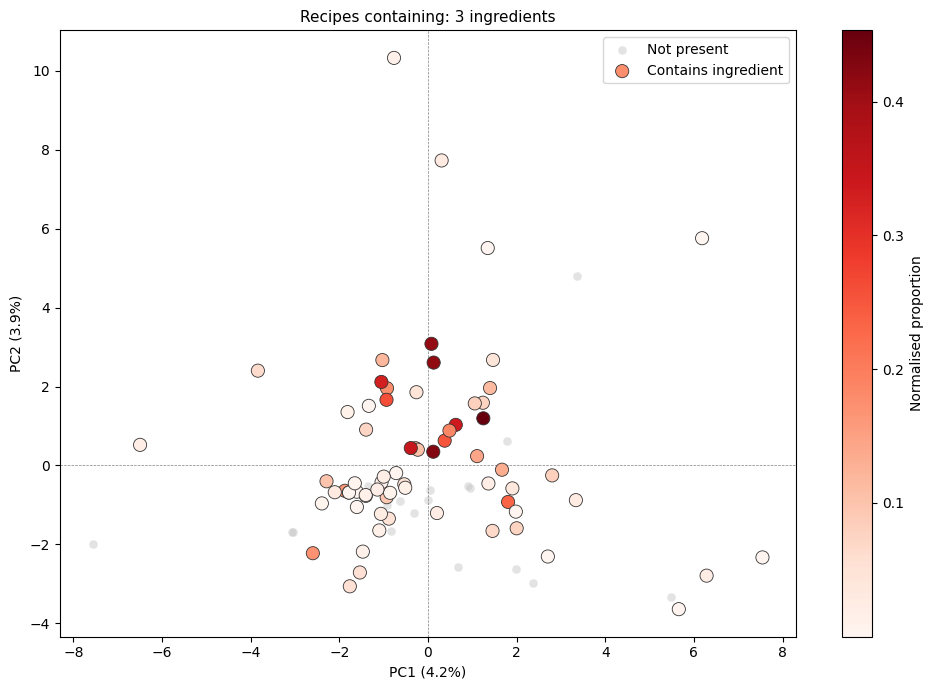

In [20]:
# ── Demo: Furaneol – the key strawberry character odorant ────────────────────
_ = find_by_ingredient('furaneol', n_top=15, plot=True)

Top PC2 driver: 928-96-1 – cis-3-Hexen-1-ol Halal Kosher

Matched 1 CAS number(s):
  928-96-1  -->  cis-3-Hexen-1-ol Halal Kosher

Present in 77 / 87 recipes (clean dataset).

          Norm_Total    PC1     PC2    PC3
Rez.-Nr.                                  
185.046     0.440079 -0.924   1.956 -0.628
188.412P    0.392468  3.365   4.804 -4.751
186.192     0.357089  0.308   7.725  0.457
186.190P    0.344461 -0.766  10.322  0.972
187.519P    0.313607  1.348   5.507  2.759
187.657P    0.272330  1.782   0.617 -1.664
188.820     0.214821  1.056   1.572 -0.007
185.239     0.197980 -0.935   1.663  3.200
185.321     0.195215  1.239   1.589  1.638
188.894     0.190807 -1.028   2.670  4.974
187.483P    0.161988  6.287  -2.790  1.216
187.753P    0.154424  0.128   2.606  0.525
187.752P    0.152797  0.079   3.081  0.594
187.897P    0.141941  2.802  -0.251  0.971
185.578P    0.135751  2.705  -2.305  0.123



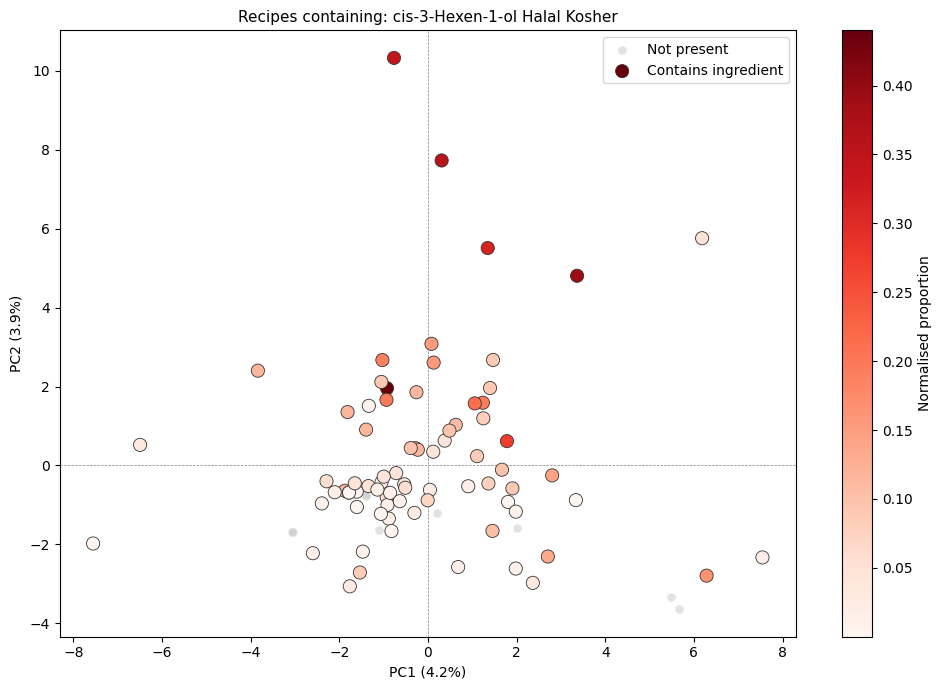

In [21]:
# ── Demo: top PC2 driver ingredient ─────────────────────────────────────────
top_pc2_cas = cas_labels[np.argmax(np.abs(loadings[1]))]
print(f'Top PC2 driver: {top_pc2_cas} – {cas_name.get(top_pc2_cas, "?")}')
print()
_ = find_by_ingredient(top_pc2_cas, n_top=15, plot=True)

---
## 10 · Virtual Recipe → Nearest Real Recipes

Specify any combination of ingredients and amounts → projected into PCA space
→ returns the closest real recipes from the clean dataset.

In [22]:
def nearest_recipes(ingredient_dict, n=10, plot=True, label='Virtual Recipe'):
    resolved = {}
    for key, amt in ingredient_dict.items():
        if key in cas_labels:
            resolved[key] = amt
        else:
            hit = next(
                (c for c in cas_labels if key.lower() in cas_name.get(c, '').lower()),
                None
            )
            if hit:
                resolved[hit] = amt
            else:
                print(f'  WARNING: {key!r} not found in model - skipped.')

    if not resolved:
        print('No valid ingredients after resolution. Aborting.')
        return None

    print(f'  {label}  -  resolved {len(resolved)} ingredient(s):')
    for cas, amt in resolved.items():
        print(f'    {cas:15s}  {cas_name.get(cas, cas).split(",")[0][:40]:40s}  norm={amt:.6f}')
    print()

    virt_vec = np.zeros(len(cas_labels))
    for cas, amt in resolved.items():
        virt_vec[cas_labels.index(cas)] = max(0.0, float(amt))
    if virt_vec.sum() > 0:
        virt_vec /= virt_vec.sum()

    virt_scaled = scaler_oav.transform(virt_vec.reshape(1, -1))[0]
    virt_score  = pca_oav.transform(virt_scaled.reshape(1, -1))[0]

    print(f'  Virtual recipe in PCA space: '
          f'PC1={virt_score[0]:+.3f}  PC2={virt_score[1]:+.3f}  PC3={virt_score[2]:+.3f}')
    print()

    dists  = np.linalg.norm(scores_oav - virt_score, axis=1)
    nn_idx = np.argsort(dists)[:n]

    result_rows = []
    print(f'  {n} nearest real recipes:')
    for rank, ri in enumerate(nn_idx, 1):
        result_rows.append({
            'Rank':     rank,
            'Rez.-Nr.': recipes_oav[ri],
            'Distance': round(dists[ri], 3),
            'PC1':      round(scores_oav[ri, 0], 3),
            'PC2':      round(scores_oav[ri, 1], 3),
            'PC3':      round(scores_oav[ri, 2], 3),
        })
        print(f'    #{rank:>2}  {recipes_oav[ri]:12s}  dist={dists[ri]:.3f}'
              f'  PC1={scores_oav[ri,0]:+.2f}  PC2={scores_oav[ri,1]:+.2f}')

    if plot:
        fig, ax = plt.subplots(figsize=(10, 7))
        ax.scatter(scores_oav[:, 0], scores_oav[:, 1],
                   c='#4A90D9', s=40, alpha=0.35, edgecolors='white', linewidths=0.3)
        for ri in nn_idx:
            ax.scatter(scores_oav[ri, 0], scores_oav[ri, 1],
                       c='#27AE60', s=90, zorder=4, edgecolors='white', linewidths=0.4)
        ax.scatter(virt_score[0], virt_score[1],
                   c='#E05A2B', s=250, marker='*', zorder=5,
                   edgecolors='#8B0000', linewidths=1.0, label=label)
        ax.axhline(0, color='grey', lw=0.5, ls='--')
        ax.axvline(0, color='grey', lw=0.5, ls='--')
        ax.set_xlabel(f'PC1 ({ev[0]:.1f}%)')
        ax.set_ylabel(f'PC2 ({ev[1]:.1f}%)')
        ax.set_title(f'Virtual Recipe Position: {label}')
        ax.legend()
        plt.tight_layout()
        plt.show()

    return pd.DataFrame(result_rows).set_index('Rank')

Demo virtual recipe (top-3 PC1 ingredients at median normalised proportion):
  105-54-4  Ethylbutyrat Kosher Halal  norm=0.077262
  116-53-0  2-Methylbuttersäure Halal Kosher  norm=0.051147
  123-92-2  Isoamylacetat Halal  norm=0.008833

  PC1 Dominant Mix  -  resolved 3 ingredient(s):
    105-54-4         Ethylbutyrat Kosher Halal                 norm=0.077262
    116-53-0         2-Methylbuttersäure Halal Kosher          norm=0.051147
    123-92-2         Isoamylacetat Halal                       norm=0.008833

  Virtual recipe in PCA space: PC1=+4.913  PC2=-1.827  PC3=-0.656

  10 nearest real recipes:
    # 1  187.897P      dist=3.901  PC1=+2.80  PC2=-0.25
    # 2  187.246P      dist=4.291  PC1=+1.98  PC2=-1.17
    # 3  187.791P      dist=5.713  PC1=+1.98  PC2=-2.61
    # 4  187.167P      dist=5.812  PC1=+5.48  PC2=-3.33
    # 5  188.560P      dist=5.872  PC1=+0.91  PC2=-0.53
    # 6  185.267       dist=6.010  PC1=+0.04  PC2=-0.62
    # 7  185.471       dist=6.167  PC1=+5.66  PC2=-

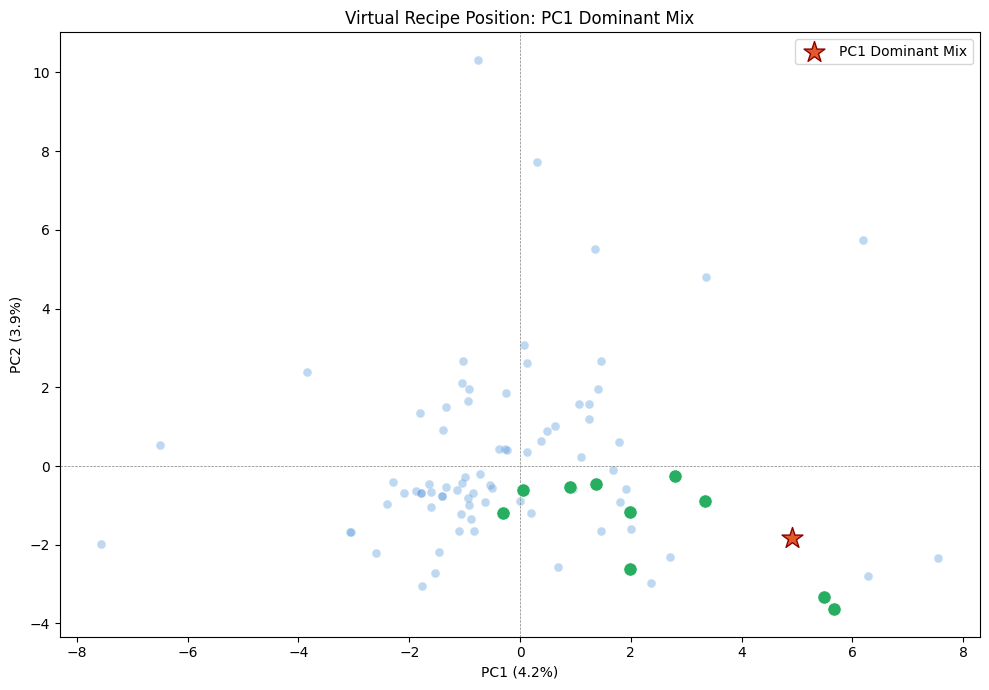

In [23]:
# -- Demo 1: auto-build virtual recipe from top PC1 ingredients --------------
top3_pc1_idx = np.argsort(np.abs(loadings[0]))[::-1][:3]
top3_pc1_cas = [cas_labels[i] for i in top3_pc1_idx]

pc1_mix = {}
for cas in top3_pc1_cas:
    if cas not in final_pivot.columns:
        continue
    vals = final_pivot.loc[final_pivot[cas] > 0, cas]
    if len(vals) == 0:
        continue
    pc1_mix[cas] = float(vals.median())

print('Demo virtual recipe (top-3 PC1 ingredients at median normalised proportion):')
for cas, amt in pc1_mix.items():
    print(f'  {cas}  {cas_name.get(cas, "?").split(",")[0][:40]}  norm={amt:.6f}')
print()
_ = nearest_recipes(pc1_mix, n=10, label='PC1 Dominant Mix')

  Furaneol + Vanillin + Linalool  -  resolved 3 ingredient(s):
    27538-09-6       Ethylfuraneol Kosher Halal                norm=0.300000
    121-33-5         Vanillin ex Eugenol                       norm=0.100000
    1365-19-1        Linalooloxid                              norm=0.050000

  Virtual recipe in PCA space: PC1=+286.540  PC2=+288.598  PC3=-377.886

  10 nearest real recipes:
    # 1  186.981P      dist=1055.422  PC1=+6.18  PC2=+5.76
    # 2  189.012       dist=1071.130  PC1=+1.40  PC2=+1.96
    # 3  187.799P      dist=1072.345  PC1=+1.25  PC2=+1.19
    # 4  187.519P      dist=1072.393  PC1=+1.35  PC2=+5.51
    # 5  187.786P      dist=1072.685  PC1=+0.96  PC2=-0.58
    # 6  188.740P      dist=1073.046  PC1=+2.00  PC2=-1.59
    # 7  187.897P      dist=1073.352  PC1=+2.80  PC2=-0.25
    # 8  188.560P      dist=1073.523  PC1=+0.91  PC2=-0.53
    # 9  185.267       dist=1073.545  PC1=+0.04  PC2=-0.62
    #10  185.984P      dist=1073.626  PC1=+3.34  PC2=-0.88


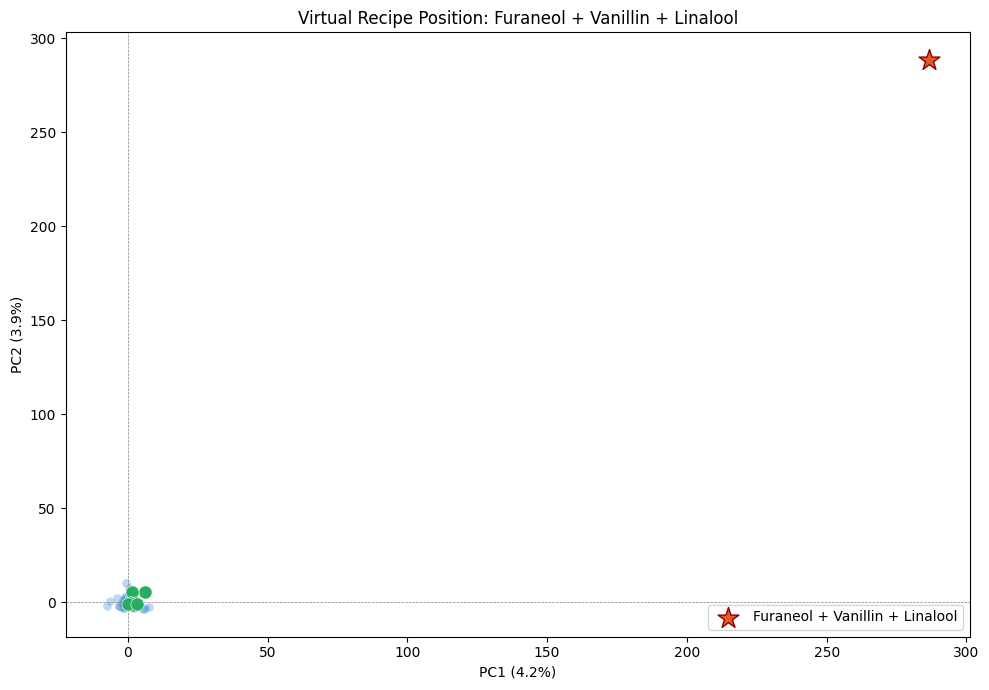

In [24]:
# -- Demo 2: freely-defined mix (edit to explore) ----------------------------
my_mix = {
    'furaneol':  0.30,
    'vanillin':  0.10,
    'linalool':  0.05,
}
_ = nearest_recipes(my_mix, n=10, label='Furaneol + Vanillin + Linalool')

---
## 11 · Full Contribution Heatmap + Attribution Export

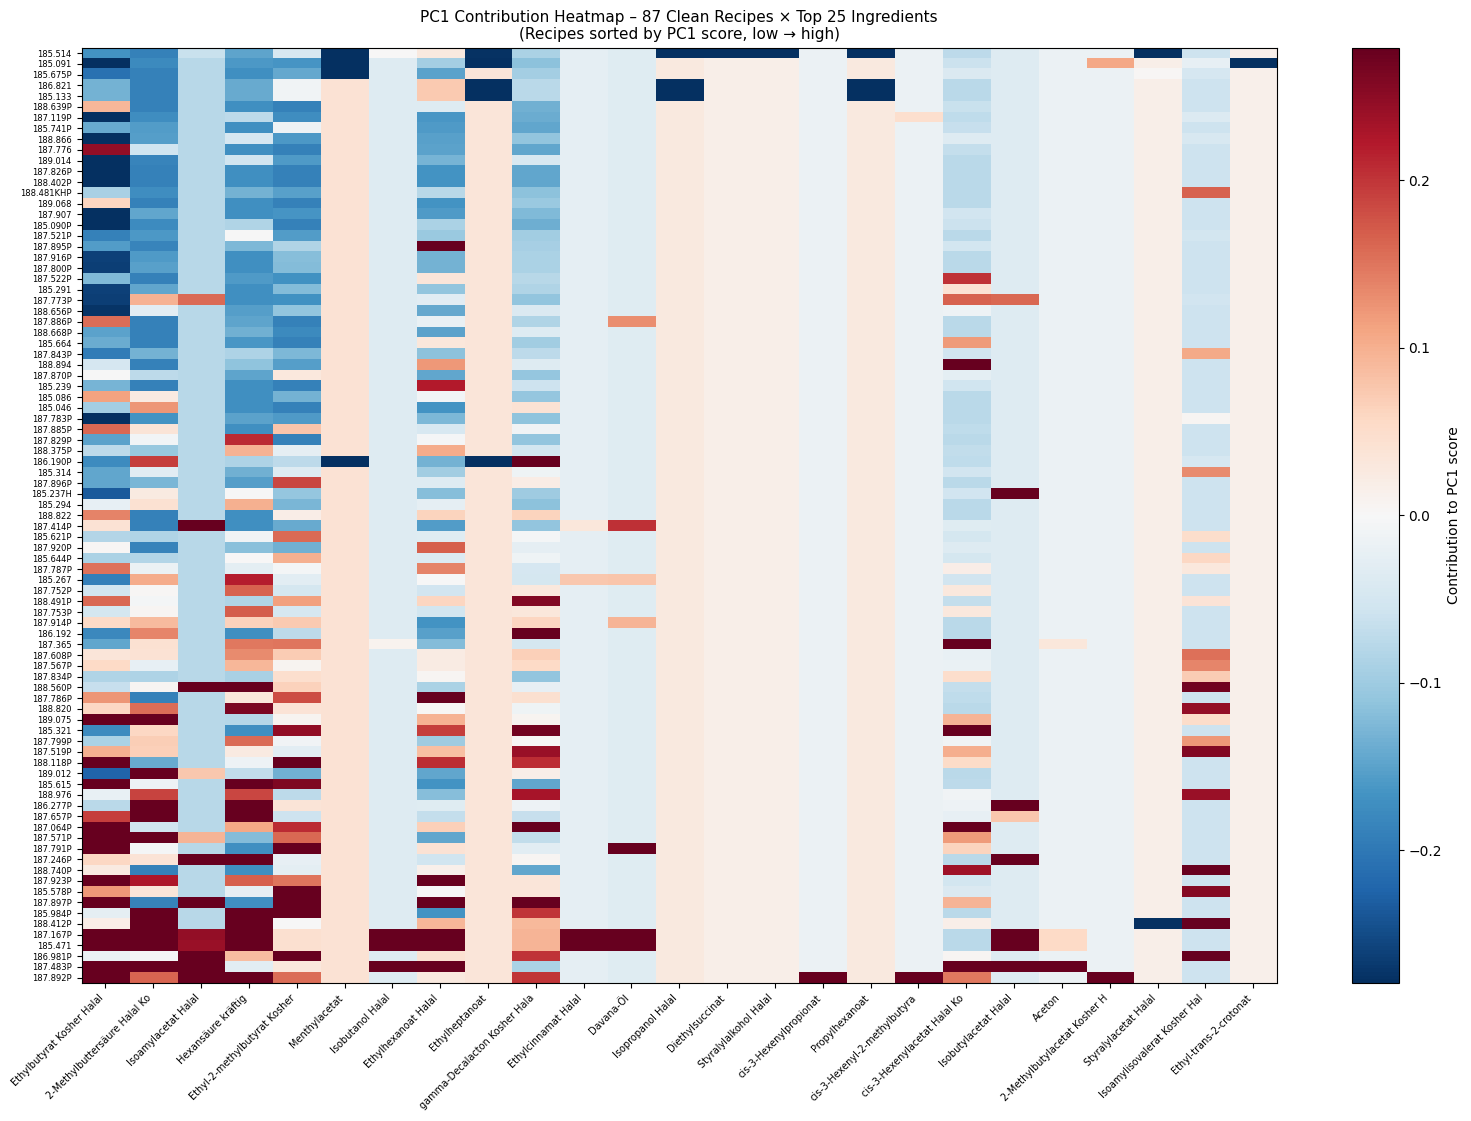

Saved: pca_v2_noOT_contrib_heatmap_pc1.png


In [25]:
# ── PC1 contribution heatmap – all clean recipes × top-25 ingredients ───────
N_ING_HEAT = 25

top25_idx = np.argsort(np.abs(loadings[0]))[::-1][:N_ING_HEAT]
top25_cas = [cas_labels[i] for i in top25_idx]
top25_lbl = [cas_name.get(c, c).split(',')[0][:28] for c in top25_cas]

contrib_pc1     = contrib[:, 0, :][:, top25_idx]
order           = np.argsort(scores_oav[:, 0])
contrib_sorted  = contrib_pc1[order]
recipe_lbl_sort = [recipes_oav[i] for i in order]

fig, ax = plt.subplots(figsize=(16, max(8, len(recipes_oav) * 0.13)))
vmax = np.percentile(np.abs(contrib_sorted), 95)
im = ax.imshow(contrib_sorted, aspect='auto', cmap='RdBu_r',
               vmin=-vmax, vmax=vmax, interpolation='nearest')
ax.set_xticks(range(N_ING_HEAT))
ax.set_xticklabels(top25_lbl, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(len(recipes_oav)))
ax.set_yticklabels(recipe_lbl_sort, fontsize=6)
plt.colorbar(im, ax=ax, label='Contribution to PC1 score')
ax.set_title(
    f'PC1 Contribution Heatmap – {len(recipes_oav)} Clean Recipes × Top {N_ING_HEAT} Ingredients\n'
    '(Recipes sorted by PC1 score, low → high)',
    fontsize=11
)
plt.tight_layout()
fig.savefig(OUT_DIR / 'pca_v2_noOT_contrib_heatmap_pc1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pca_v2_noOT_contrib_heatmap_pc1.png')

In [26]:
# ── Export: per-recipe top-5 ingredient driver per PC → CSV ─────────────────
export_rows = []
for r_idx, rez in enumerate(recipes_oav):
    row = {'Rez.-Nr.': rez}
    for k in range(N_PC_ATTR):
        c_vec = contrib[r_idx, k]
        top5  = np.argsort(np.abs(c_vec))[::-1][:5]
        row[f'PC{k+1}_score'] = round(scores_oav[r_idx, k], 4)
        for rank, i in enumerate(top5, 1):
            cas  = cas_labels[i]
            name = cas_name.get(cas, cas).split(',')[0][:35]
            row[f'PC{k+1}_top{rank}_cas']    = cas
            row[f'PC{k+1}_top{rank}_name']   = name
            row[f'PC{k+1}_top{rank}_contrib'] = round(float(c_vec[i]), 5)
    export_rows.append(row)

attr_df = pd.DataFrame(export_rows).set_index('Rez.-Nr.')
attr_df.to_csv(OUT_DIR / 'pca_v2_noOT_recipe_attribution.csv')
print('Exported: pca_v2_noOT_recipe_attribution.csv')
print(f'Shape: {attr_df.shape}')

Exported: pca_v2_noOT_recipe_attribution.csv
Shape: (87, 64)


---
## 12 · Top 20 Ingredients per Recipe (PCA Contribution Export)

For every recipe the 20 ingredients that contribute most to its PCA fingerprint.
Only ingredients actually present in the recipe (Norm_Totalmenge > 0) are included.

In [27]:
total_abs_contrib = np.abs(contrib).sum(axis=1)  # (n_recipes, n_cas)
N_TOP_PER_RECIPE  = 20
rows = []

for r_idx, rez in enumerate(recipes_oav):
    present_mask   = final_pivot.iloc[r_idx].values > 0
    present_idx    = np.where(present_mask)[0]
    if len(present_idx) == 0:
        continue
    contribs_pres  = total_abs_contrib[r_idx][present_idx]
    top_k          = min(N_TOP_PER_RECIPE, len(present_idx))
    top_local      = np.argsort(contribs_pres)[::-1][:top_k]
    top_idx_abs    = present_idx[top_local]

    for rank, i in enumerate(top_idx_abs, 1):
        cas = cas_labels[i]
        rows.append({
            'Rez.-Nr.':        rez,
            'Rank':            rank,
            'CAS':             cas,
            'Ingredient':      cas_name.get(cas, cas),
            'Norm_Totalmenge': round(float(final_pivot.iloc[r_idx, i]), 6),
            'Total_Contrib':   round(float(total_abs_contrib[r_idx, i]), 5),
            'PC1_Contrib':     round(float(contrib[r_idx, 0, i]), 5),
            'PC2_Contrib':     round(float(contrib[r_idx, 1, i]), 5),
            'PC3_Contrib':     round(float(contrib[r_idx, 2, i]), 5),
            'PC4_Contrib':     round(float(contrib[r_idx, 3, i]), 5),
        })

top20_df = pd.DataFrame(rows)
print(f'Shape: {top20_df.shape}')
print(f'Recipes covered: {top20_df["Rez.-Nr."].nunique()}')
print(f'All Norm_Totalmenge > 0: {(top20_df["Norm_Totalmenge"] > 0).all()}')
print()
print(top20_df.head(20).to_string(index=False))

top20_df.to_csv(OUT_DIR / 'pca_v2_noOT_top20_per_recipe.csv', index=False)
top20_df.to_excel(OUT_DIR / 'pca_v2_noOT_top20_per_recipe.xlsx', index=False)
print('\nExported: pca_v2_noOT_top20_per_recipe.csv / .xlsx')

Shape: (1533, 10)
Recipes covered: 87
All Norm_Totalmenge > 0: True

Rez.-Nr.  Rank        CAS                         Ingredient  Norm_Totalmenge  Total_Contrib  PC1_Contrib  PC2_Contrib  PC3_Contrib  PC4_Contrib
 185.046     1   928-96-1      cis-3-Hexen-1-ol Halal Kosher         0.440079        1.61221      0.25127      1.18959      0.12627      0.04509
 185.046     2   110-43-0                   2-Heptanon Halal         0.019646        0.70537     -0.16510      0.37258     -0.12752      0.04016
 185.046     3   109-21-7                 Butylbutyrat Halal         0.145383        0.69960     -0.16330      0.37311     -0.12528      0.03790
 185.046     4  8022-96-6      Jasmin-Absolue (blumig) Halal         0.001965        0.38261      0.13791     -0.01154     -0.19713     -0.03603
 185.046     5  3658-77-3                     Furaneol Halal         0.176817        0.26217      0.00068      0.09548      0.07253      0.09348
 185.046     6   116-53-0   2-Methylbuttersäure Halal Kosher 

---
## 13 · Top 20 Ingredients Globally (Across All Clean Recipes)

=== Top 20 Ingredients Globally ===
 Rank        CAS                                      Ingredient  Global_Importance  Frequency  Recipes_Count  Avg_Norm_Present  PC1_Loading  PC2_Loading  PC3_Loading  PC4_Loading
    1  1754-62-7                     Methyl-trans-cinnamat Halal            36.0639     0.4598             40          0.058822       0.0799       0.1904       0.1680      -0.0843
    2   706-14-9                   gamma-Decalacton Kosher Halal            32.4010     0.9540             83          0.035530       0.1628       0.2655      -0.0132      -0.1161
    3   659-70-1                  Isoamylisovalerat Kosher Halal            32.1475     0.3218             28          0.007990       0.1244       0.1263      -0.0756       0.2111
    4   105-54-4                       Ethylbutyrat Kosher Halal            29.6257     1.0000             87          0.099655       0.2634      -0.1256       0.0010      -0.0597
    5   111-27-3                            Hexanol Kosher Halal

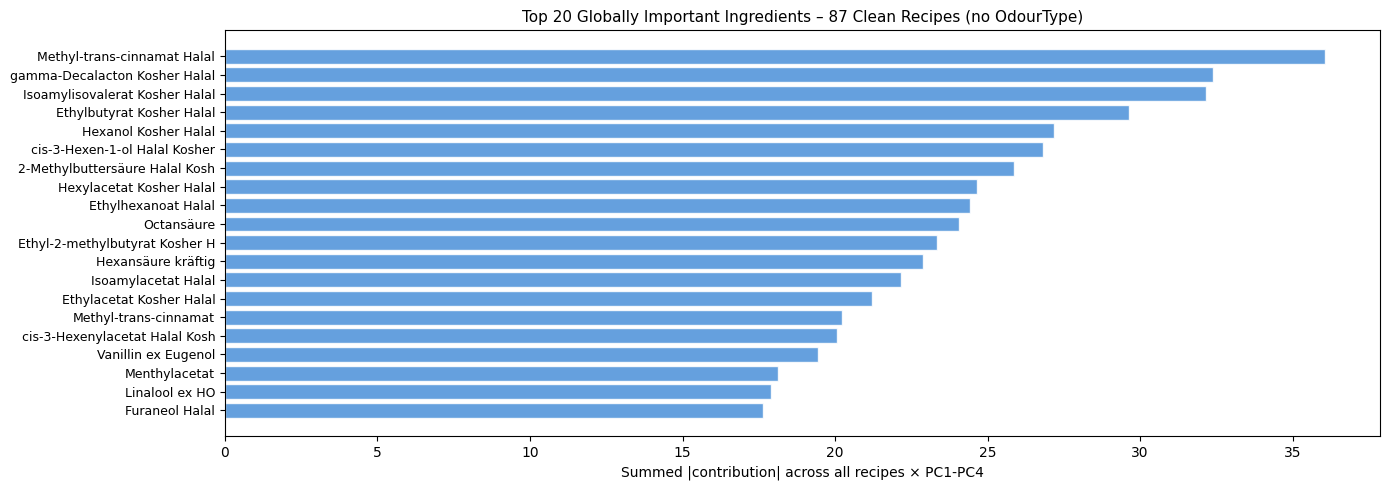

Saved: pca_v2_noOT_top20_global_bar.png


In [28]:
global_importance    = np.abs(contrib).sum(axis=(0, 1))  # (n_cas,)
top20_global_idx     = np.argsort(global_importance)[::-1][:20]

global_rows = []
for rank, i in enumerate(top20_global_idx, 1):
    cas = cas_labels[i]
    col = final_pivot.iloc[:, i]
    global_rows.append({
        'Rank':              rank,
        'CAS':               cas,
        'Ingredient':        cas_name.get(cas, cas),
        'Global_Importance': round(float(global_importance[i]), 4),
        'Frequency':         round(float((col > 0).mean()), 4),
        'Recipes_Count':     int((col > 0).sum()),
        'Avg_Norm_Present':  round(float(col[col > 0].mean() if (col > 0).any() else 0), 6),
        'PC1_Loading':       round(float(loadings[0, i]), 4),
        'PC2_Loading':       round(float(loadings[1, i]), 4),
        'PC3_Loading':       round(float(loadings[2, i]), 4),
        'PC4_Loading':       round(float(loadings[3, i]), 4),
    })

top20_global_df = pd.DataFrame(global_rows)
print('=== Top 20 Ingredients Globally ===')
print(top20_global_df.to_string(index=False))

top20_global_df.to_csv(OUT_DIR / 'pca_v2_noOT_top20_ingredients_global.csv', index=False)
top20_global_df.to_excel(OUT_DIR / 'pca_v2_noOT_top20_ingredients_global.xlsx', index=False)
print('\nExported: pca_v2_noOT_top20_ingredients_global.csv / .xlsx')

names_short = [cas_name.get(cas_labels[i], cas_labels[i]).split(',')[0][:30]
               for i in top20_global_idx]
fig, ax = plt.subplots(figsize=(14, 5))
ax.barh(range(20), global_importance[top20_global_idx[::-1]],
        color='#4A90D9', alpha=0.85, edgecolor='white')
ax.set_yticks(range(20))
ax.set_yticklabels(names_short[::-1], fontsize=9)
ax.set_xlabel('Summed |contribution| across all recipes × PC1-PC4', fontsize=10)
ax.set_title(
    f'Top 20 Globally Important Ingredients – {len(recipes_oav)} Clean Recipes (no OdourType)',
    fontsize=11
)
plt.tight_layout()
fig.savefig(OUT_DIR / 'pca_v2_noOT_top20_global_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pca_v2_noOT_top20_global_bar.png')

---
## 14 · Top 20 Ingredients per Recipe & Globally – Full Original Dataset (all 129 Recipes)

This section repeats the Top-20 analysis on the **complete original dataset** (all 129 recipes,
before any outlier removal). A fresh PCA is fitted on the full dataset so that contributions
are computed in the original full-data PCA space — comparable to iteration 1 of the iterative process.

In [29]:
# ── Fit PCA on full original dataset (all 129 recipes) ──────────────────────
recipes_orig   = list(pivot_oav.index)          # all 129
X_oav_orig     = pivot_oav.values.copy()         # 129 × n_cas

scaler_orig    = StandardScaler()
X_orig_sc      = scaler_orig.fit_transform(X_oav_orig)

n_comp_orig    = min(10, X_orig_sc.shape[1], X_orig_sc.shape[0] - 1)
pca_orig       = PCA(n_components=n_comp_orig, random_state=42)
scores_orig    = pca_orig.fit_transform(X_orig_sc)
ev_orig        = pca_orig.explained_variance_ratio_ * 100
loadings_orig  = pca_orig.components_

print(f'Original dataset PCA: {len(recipes_orig)} recipes × {X_oav_orig.shape[1]} CAS')
print(f'PC1={ev_orig[0]:.1f}%  PC2={ev_orig[1]:.1f}%  PC3={ev_orig[2]:.1f}%  (cumulative 3: {ev_orig[:3].sum():.1f}%)')

# Contribution tensor for all 129 recipes
N_PC_ORIG  = 4
contrib_orig = X_orig_sc[:, np.newaxis, :] * loadings_orig[np.newaxis, :N_PC_ORIG, :]  # (129, 4, n_cas)

recipe_idx_orig = {r: idx for idx, r in enumerate(recipes_orig)}
print(f'Contribution tensor shape: {contrib_orig.shape}')

Original dataset PCA: 129 recipes × 225 CAS
PC1=5.2%  PC2=4.8%  PC3=4.0%  (cumulative 3: 14.0%)
Contribution tensor shape: (129, 4, 225)


In [30]:
# ── Top 20 ingredients per recipe – all 129 original recipes ────────────────
N_TOP_ORIG         = 20
total_abs_orig     = np.abs(contrib_orig).sum(axis=1)  # (129, n_cas)
rows_orig          = []

for r_idx, rez in enumerate(recipes_orig):
    present_mask = pivot_oav.iloc[r_idx].values > 0
    present_idx  = np.where(present_mask)[0]
    if len(present_idx) == 0:
        continue
    contribs_pres = total_abs_orig[r_idx][present_idx]
    top_k         = min(N_TOP_ORIG, len(present_idx))
    top_local     = np.argsort(contribs_pres)[::-1][:top_k]
    top_idx_abs   = present_idx[top_local]

    outlier_flag = rez not in recipe_idx_map  # True if this recipe was removed

    for rank, i in enumerate(top_idx_abs, 1):
        cas = cas_labels[i]
        rows_orig.append({
            'Rez.-Nr.':        rez,
            'Outlier_Removed': outlier_flag,
            'Rank':            rank,
            'CAS':             cas,
            'Ingredient':      cas_name.get(cas, cas),
            'Norm_Totalmenge': round(float(pivot_oav.iloc[r_idx, i]), 6),
            'Total_Contrib':   round(float(total_abs_orig[r_idx, i]), 5),
            'PC1_Contrib':     round(float(contrib_orig[r_idx, 0, i]), 5),
            'PC2_Contrib':     round(float(contrib_orig[r_idx, 1, i]), 5),
            'PC3_Contrib':     round(float(contrib_orig[r_idx, 2, i]), 5),
            'PC4_Contrib':     round(float(contrib_orig[r_idx, 3, i]), 5),
        })

top20_orig_df = pd.DataFrame(rows_orig)
n_rec_covered = top20_orig_df['Rez.-Nr.'].nunique()
n_flagged     = top20_orig_df[top20_orig_df['Outlier_Removed']]['Rez.-Nr.'].nunique()
print(f'Shape: {top20_orig_df.shape}')
print(f'Recipes covered: {n_rec_covered} (of which {n_flagged} were removed as outliers in iterative PCA)')
print(f'All Norm_Totalmenge > 0: {(top20_orig_df["Norm_Totalmenge"] > 0).all()}')
print()
print(top20_orig_df.head(20).to_string(index=False))

top20_orig_df.to_csv(OUT_DIR / 'pca_v2_noOT_top20_per_recipe_all129.csv', index=False)
top20_orig_df.to_excel(OUT_DIR / 'pca_v2_noOT_top20_per_recipe_all129.xlsx', index=False)
print('\nExported: pca_v2_noOT_top20_per_recipe_all129.csv / .xlsx')

Shape: (2344, 11)
Recipes covered: 129 (of which 42 were removed as outliers in iterative PCA)
All Norm_Totalmenge > 0: False

Rez.-Nr.  Outlier_Removed  Rank         CAS                                       Ingredient  Norm_Totalmenge  Total_Contrib  PC1_Contrib  PC2_Contrib  PC3_Contrib  PC4_Contrib
 185.028             True     1     97-62-1                            Ethylisobutyrat Halal         0.003501        1.51250      0.56216      0.88338      0.05006      0.01690
 185.028             True     2   6728-26-3                     trans-2-Hexenal Kosher Halal         0.003889        0.75796      0.00821     -0.04129     -0.18458      0.52388
 185.028             True     3     78-70-6        Linalool ex HO, natürlich Kosher Halal BG         0.005445        0.60283      0.22306     -0.19366      0.16129      0.02482
 185.028             True     4  27625-35-0               Isoamyl-2-methylbutyrat, natürlich         0.001945        0.49667      0.00764     -0.02522     -0.12365  

=== Top 20 Ingredients Globally – All 129 Original Recipes ===
 Rank        CAS                                Ingredient  Global_Importance  Frequency  Recipes_Count  Avg_Norm_Present  PC1_Loading  PC2_Loading  PC3_Loading  PC4_Loading
    1   142-92-7                  Hexylacetat Kosher Halal            29.6281     0.5116             66          0.008638       0.0048      -0.0228      -0.0971       0.2674
    2   659-70-1            Isoamylisovalerat Kosher Halal            28.9910     0.3798             49          0.011154      -0.0088      -0.0165      -0.0890       0.2448
    3   108-64-5              Ethylisovalerat Kosher Halal            26.4767     0.5814             75          0.015013       0.0431       0.0881      -0.0513       0.1321
    4   106-27-4                      Isoamylbutyrat Halal            21.2149     0.1938             25          0.009425      -0.0015      -0.0174      -0.0871       0.2380
    5    66-25-1                      Hexanal Kosher Halal         

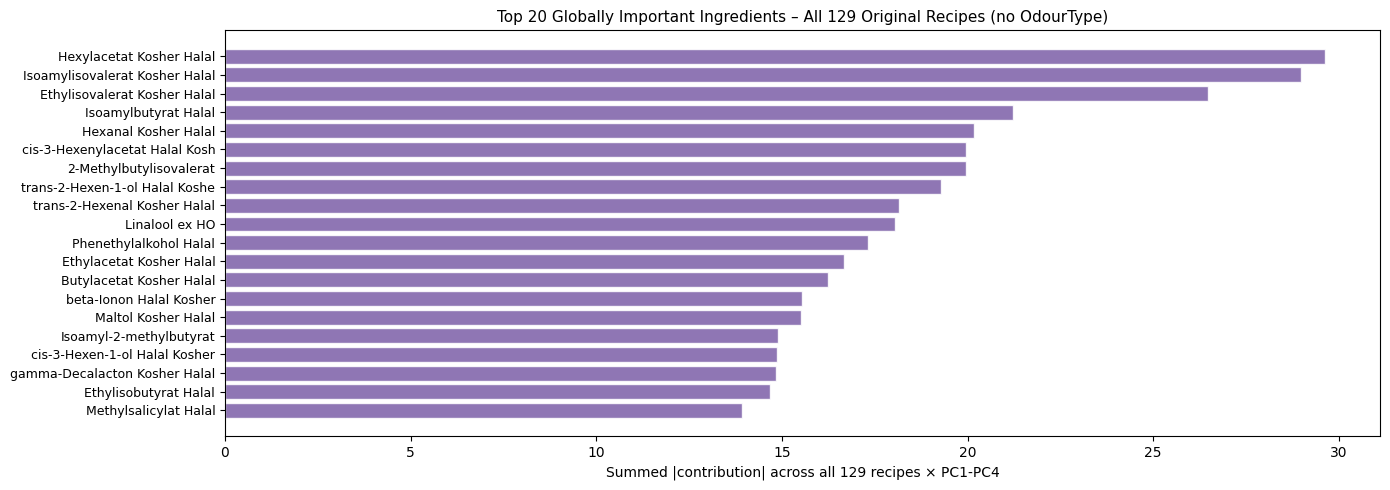

Saved: pca_v2_noOT_top20_global_bar_all129.png


In [31]:
# ── Top 20 ingredients globally – all 129 original recipes ──────────────────
global_imp_orig     = np.abs(contrib_orig).sum(axis=(0, 1))  # (n_cas,)
top20_g_orig_idx    = np.argsort(global_imp_orig)[::-1][:20]

global_orig_rows = []
for rank, i in enumerate(top20_g_orig_idx, 1):
    cas = cas_labels[i]
    col = pivot_oav.iloc[:, i]
    global_orig_rows.append({
        'Rank':              rank,
        'CAS':               cas,
        'Ingredient':        cas_name.get(cas, cas),
        'Global_Importance': round(float(global_imp_orig[i]), 4),
        'Frequency':         round(float((col > 0).mean()), 4),
        'Recipes_Count':     int((col > 0).sum()),
        'Avg_Norm_Present':  round(float(col[col > 0].mean() if (col > 0).any() else 0), 6),
        'PC1_Loading':       round(float(loadings_orig[0, i]), 4),
        'PC2_Loading':       round(float(loadings_orig[1, i]), 4),
        'PC3_Loading':       round(float(loadings_orig[2, i]), 4),
        'PC4_Loading':       round(float(loadings_orig[3, i]), 4),
    })

top20_g_orig_df = pd.DataFrame(global_orig_rows)
print('=== Top 20 Ingredients Globally – All 129 Original Recipes ===')
print(top20_g_orig_df.to_string(index=False))

top20_g_orig_df.to_csv(OUT_DIR / 'pca_v2_noOT_top20_ingredients_global_all129.csv', index=False)
top20_g_orig_df.to_excel(OUT_DIR / 'pca_v2_noOT_top20_ingredients_global_all129.xlsx', index=False)
print('\nExported: pca_v2_noOT_top20_ingredients_global_all129.csv / .xlsx')

names_short_orig = [cas_name.get(cas_labels[i], cas_labels[i]).split(',')[0][:30]
                    for i in top20_g_orig_idx]
fig, ax = plt.subplots(figsize=(14, 5))
ax.barh(range(20), global_imp_orig[top20_g_orig_idx[::-1]],
        color='#7B5EA7', alpha=0.85, edgecolor='white')
ax.set_yticks(range(20))
ax.set_yticklabels(names_short_orig[::-1], fontsize=9)
ax.set_xlabel('Summed |contribution| across all 129 recipes × PC1-PC4', fontsize=10)
ax.set_title(
    'Top 20 Globally Important Ingredients – All 129 Original Recipes (no OdourType)',
    fontsize=11
)
plt.tight_layout()
fig.savefig(OUT_DIR / 'pca_v2_noOT_top20_global_bar_all129.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pca_v2_noOT_top20_global_bar_all129.png')

---
## 14 · Key Findings (v2 - No Threshold, No OdourType)

### Data Processing
- Ignore list applied (CAS-based masking) before any analysis.
- Totalmenge normalised per recipe (sum = 1) — no log transform, no OAV threshold.
- OdourType information intentionally excluded to let the chemical fingerprint speak alone.

### Outlier Removal
- Iterative 2D Mahalanobis outlier detection in PC1-PC2 space (threshold = 3σ).
- Process repeats until no outliers remain or 20 iterations are exhausted.
- See Section 8 for the full outlier log.

### Interpretation
- PC1 captures the dominant compositional axis (major aroma directions).
- PC2 captures secondary compositional variation.
- Clusters in this space represent recipes with similar CAS-level fingerprints,
  independent of any odour-type classification.
- The biplot arrows show which specific ingredients drive cluster separation.

## Summary

| | Value |
|---|---|
| Recipes analysed (start) | — |
| Recipes after outlier removal | — |
| CAS features | — |
| Outlier threshold | 3σ Mahalanobis (2D PC1-PC2) |
| OdourType | Not used |
| Outputs | `outputs/pca_v2_noOT_*` |